# Genre Bias in the Academy Awards: A Statistical Analysis of Oscar Winning Films

**Group Members:** Edison Ayran, Diego Inostroza, Harshini Sangaraju

In [1]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.sandbox.stats.runs import runstest_1samp
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Introduction

This project investigates whether the genre of a film influences its probability of winning an Academy Award. The Academy Awards are widely regarded as one of the most prestigious honors in the film industry, and winning an Oscar can significantly impact a film’s cultural recognition, financial success, and the careers of those involved. Because of this influence, it is important to examine whether certain types of films are systematically favored in award outcomes. Using data from the Academy Awards database and the IMDb dataset, this analysis explores whether genres such as Drama or Biography which are often considered “prestige genres,” are more likely to win awards than genres such as Action, Comedy, or Horror. By combining award data with film metadata, this project aims to statistically evaluate whether genre plays a meaningful role in Oscar success.

# Problem Statement

Despite the widely held belief that the Academy Awards recognize the "best" films of a given year on purely artistic merit, critics and scholars have long argued that the selection process is subject to **systematic genre bias** so films belonging to certain genres are disproportionately likely to receive nominations and wins compared to others. Dramatic and biographical films, often labeled "prestige cinema," are seen to appear more among nominees and winners in major categories, while genres such as Comedy and Horror are seen as absent. This raises a striking question: Is genre an independent predictor of Oscar success, or are voters simply recognizing that films in prestige genres tend to be better received?

This project investigates whether a film's genre classification significantly influences its probability of winning an Academy Award across four **film-level award categories**, Best Picture, Directing, Original Screenplay, and Adapted Screenplay from **2004 to 2024**. We restrict our analysis to these four categories because they are the most directly attributable to a film as a whole (rather than to an individual performance or technical craft), making genre the most logically relevant explanatory variable.

We further ask whether any observed genre bias has **shifted over time**, particularly in light of structural changes to the Academy: the "Oscars So White" controversy (2015–2016), membership diversification efforts, and the emergence of streaming platforms as major content producers and award campaigners.

To construct our comparison group, we analyze all 486 nominations from these four categories during our study period, comparing the 84 winning films against the 402 non-winning nominees. This design allows us to isolate the effect of genre on winning probability among films that were already deemed worthy of 
nomination by the Academy, with genre as the primary explanatory variable while controlling for film quality, popularity, and temporal factors.

# Relevance and Motivation

The Academy Awards represent the pinnacle of recognition in the film industry, where winning significantly impacts a film’s cultural influence, financial success, and the career trajectories of its creators. Because the Oscars serve as a definitive metric of "excellence," it is crucial to investigate whether this definition is genre-agnostic or subject to systemic institutional bias. There has long been a prevailing belief that "prestige" genres, such as Drama and historical biopics, receive disproportionate representation among winners, while genres like Action, Comedy, and Horror—despite their commercial and critical prevalence—are systematically overlooked in major categories. Investigating this problem is essential because award trends directly shape the industry by influencing which stories production studios choose to fund and which narratives achieve mainstream prominence.

Moreover, the landscape of the film industry has shifted significantly over the last two decades due to the emergence of streaming platforms and major structural reforms within the Academy, such as membership diversification initiatives following the 2015–2016 "Oscars So White" controversy. These changes provide a unique opportunity to evaluate whether the relationship between genre and award success has evolved or if "prestige" cinema maintains a persistent structural advantage in the voting process. By statistically evaluating award outcomes across major film-level categories from 2004 to 2024, this project aims to provide empirical evidence to determine whether the Academy’s voting patterns reflect a genuine shift toward a more genre-diverse recognition of cinematic excellence or if institutional biases remain entrenched.

# Objective

Determine whether movie genre significantly influences the probability of winning an Academy
Award across four major film-level categories (Best Picture, Directing, Original Screenplay,
Adapted Screenplay) from 2004–2024, and test whether this relationship has changed
meaningfully between the pre-reform era (2004–2014) and the post-reform era (2015–2024)
using chi-squared tests of independence, the Wald-Wolfowitz runs test, and logistic
regression with genre indicator variables and genre × year interaction terms.

### Research Question

**Among films nominated for an Academy Award in the categories of Best Picture, Directing, Original Screenplay, and Adapted Screenplay between 2004 and 2024, does a film's genre classification significantly influence its probability of winning, and has this relationship changed over the last two decades?**

More specifically: Among nominated films, those already deemed worthy of consideration by Academy voters are "prestige" genres such as Drama and Biography, systematically over-represented among winners relative to their share of nominations? And if so, has the post-2015 era of Academy membership reform produced a measurable reduction in this genre-based advantage?

By restricting our study population to nominees only, we ensure that every film in our dataset had a realistic chance of winning. This framing separates genre bias in *winning* from genre bias in *nomination* our analysis speaks specifically to what distinguishes winners from non-winning nominees, not what distinguishes Oscar films from the general film landscape.

# Data Sources

We gathered our data from two separate sources, the IMDb dataset and an Academy Awards dataset. IMDb is an online database that contains information about various forms of media, including movies. On their website, they also provide a publicly downloadable version of their updated dataset files meant for non-commercial use. Our Academy Awards dataset was taken from Kaggle. It was gathered by scraping the official Academy Awards search site, letting it contain all officially recorded award winners and nominees. For our specific dataset, we can obtain our data by cleaning and merging the datasets in order to find the genres of the listed movies in the Academy Awards dataset.

# Previous Analyses on Similar Datasets


#### Sentiment Analysis
- https://www.kaggle.com/code/lakshmi25npathi/sentiment-analysis-of-imdb-movie-reviews
 
On another IMDb dataset listed on Kaggle, some projects have created classification models to analyze the sentiment of movie reviews. This particular project compared multiple approaches to sentiment analysis. A logistic regression model, linear support vector machines, and a multinomial naive bayes model. Each approach was also trained with a bag of words and tf-idf features. This led to 6 different trained models, which were ultimately compared to find the most accurate model.

#### IMDb EDA
- https://www.linkedin.com/pulse/databricks-project-using-datasets-from-imdb-streaming-mosquera-oe5xe

This project focused on performing EDA using the IMDb datasets we utilized. It aimed to explore the data of movies between 2019 and 2024 through different charts and graphs. Rather than having one specific focus, it explored the distribution of title types, the most successful movie directors, regions that have the most movie releases, and several other topics. The project broadly gave insights to the IMDb dataset, providing visualizations to various trends in the data.

#### Data Visualization of the Oscars
- https://www.kaggle.com/code/yli864/visualization-and-analysis-of-oscar-data-by-python

This project solely focused on the Academy Awards dataset, performing EDA to explore the distributions of nominations and categories, along with the relationships between listed columns. For example, one graph compared the number of awards given to the people who received the most awards according to the dataset. Similarly to the IMDb EDA project, this analysis broadly gave insights to the data, showing the top films, director

### How Our Project is Different
While other projects usually focused on one of the datasets, our project utilized both in order to analyze how the genres of movies impact their chances of being included in the academy awards. When looking through other analyses, we didn’t see any projects which aimed to explore this relationship. We also were able to utilize concepts like the chi-squared test of independence and Wald-Wolfowitz runs test, which we didn't see when looking through previous works related to our question.


# Description of Variables

**From `full_data.csv`:**

| Column              | Type    | Description |
|---------------------|---------|-------------|
| `FilmId`            | string  | IMDb tconst (e.g. `tt0081398`) - primary merge key with IMDb datasets |
| `Film`              | string  | Title of the nominated film |
| `Year`              | string  | Ceremony year (e.g. `2004/05`) |
| `CanonicalCategory` | string  | Standardized category name - filtered to our 4 target categories |
| `Category`          | string  | Raw category label as listed in the official Academy database |
| `Winner`            | boolean | True if the film won; NaN treated as False (nominated but did not win) |
| `Name`              | string  | Person associated with the nomination (director or writer) |

**From `title.basics.tsv.gz`:**

| Column           | Type   | Description |
|------------------|--------|-------------|
| `tconst`         | string | IMDb title identifier - merge key |
| `genres`         | string | Comma-separated genre tags, up to 3 per film (e.g. `Drama,Biography,History`) |
| `runtimeMinutes` | float  | Film runtime in minutes - regression control variable |
| `titleType`      | string | Used to pre-filter to movies only before merging |
| `startYear`      | int    | Release year - used to cross-validate ceremony year |

**From `title.ratings.tsv.gz`:**

| Column          | Type   | Description |
|-----------------|--------|-------------|
| `tconst`        | string | IMDb title identifier - merge key |
| `averageRating` | float  | Weighted average IMDb user rating (scale 1–10) |
| `numVotes`      | int    | Total number of user ratings received |

**Engineered during cleaning:**

| Column          | Type   | Description |
|-----------------|--------|-------------|
| `primary_genre` | string | First genre extracted from `genres` - core categorical predictor in all 3 tests |
| `outcome`       | int    | Binary re-encoding of `Winner` - 1 if won, 0 if nominated only |
| `era`           | int    | 0 = pre-reform (2004–2014), 1 = post-reform (2015–2024) |
| `log_votes`     | float  | Log-transformed `numVotes` to reduce right skew before regression |

## Dataset Composition

Our analysis uses three files merged via IMDb tconst identifiers.

**`full_data.csv` (Primary Oscar Source)**
Contains 12,014 nomination records across all Academy Award categories from 1927–2025.
Each record includes a `FilmId` column with an IMDb tconst (e.g. `tt0081398`),
enabling a clean exact join with IMDb
After filtering to our 4 target categories and ceremony years 2004–2024:

| Category                       | Nominations | Winners |
|--------------------------------|-------------|---------|
| BEST PICTURE                   | 171         | 21      |
| DIRECTING                      | 105         | 21      |
| WRITING (Original Screenplay)  | 105         | 21      |
| WRITING (Adapted Screenplay)   | 105         | 21      |
| **Total**                      | **486**     | **84**  |

**`title.basics.tsv.gz` (IMDb)**
Covers ~10 million IMDb titles. Provides genre classifications (up to 3 per film),
runtime in minutes, title type, and release year. Filtered to `titleType == 'movie'`
before merging.

**`title.ratings.tsv.gz` (IMDb)**
Provides weighted average user rating and total vote count for all rated titles.
Joined to basics on `tconst`, then merged with the Oscar records on `FilmId = tconst`.

Final working dataset (final_df) used for all analysis: 486 nominations 
(84 winners and 402 non-winning nominees from our 4 target award categories), 
across 13 analytical columns including genre, rating, runtime, and temporal indicators.

## Load the Data ##

In [2]:
# Full Oscar dataset 
oscars_raw = pd.read_csv('full_data.csv', sep='\t', low_memory=False)

# IMDb title.basics 
imdb_basics = pd.read_csv(
    'title.basics.tsv.gz',
    sep='\t',
    compression='gzip',
    low_memory=False,
    na_values='\\N'
)

# IMDb title.ratings 
imdb_ratings = pd.read_csv(
    'title.ratings.tsv.gz',
    sep='\t',
    compression='gzip',
    na_values='\\N'
)

print("Oscar records :", oscars_raw.shape)   
print("IMDb basics   :", imdb_basics.shape)
print("IMDb ratings  :", imdb_ratings.shape)

oscars_raw.head()

Oscar records : (12014, 16)
IMDb basics   : (12354331, 9)
IMDb ratings  : (1642919, 3)


,Ceremony,Year,Class,CanonicalCategory,Category,NomId,Film,FilmId,Name,Nominees,NomineeIds,Winner,Detail,Note,Citation,MultifilmNomination
0,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051251,The Noose,tt0019217,Richard Barthelmess,Richard Barthelmess,nm0001932,NaN,Nickie Elkins,NaN,NaN,True
1,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051252,The Patent Leather Kid,tt0018253,Richard Barthelmess,Richard Barthelmess,nm0001932,NaN,The Patent Leather Kid,NaN,NaN,True
2,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051250a,The Last Command,tt0019071,Emil Jannings,Emil Jannings,nm0417837,True,General Dolgorucki [Grand Duke Sergius Alexander],NaN,NaN,True
3,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051250b,The Way of All Flesh,tt0019553,Emil Jannings,Emil Jannings,nm0417837,True,August Schilling,NaN,NaN,True
4,1,1927/28,Acting,ACTRESS IN A LEADING ROLE,ACTRESS,an0051255,A Ship Comes In,tt0018389,Louise Dresser,Louise Dresser,nm0237571,NaN,Mrs. Pleznik,NaN,NaN,NaN


In [3]:
imdb_basics.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894.0,NaN,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892.0,NaN,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892.0,NaN,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892.0,NaN,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893.0,NaN,1,Short


In [4]:
imdb_ratings.head()

,tconst,averageRating,numVotes
0,tt0000001,5.7,2197
1,tt0000002,5.5,309
2,tt0000003,6.5,2302
3,tt0000004,5.1,196
4,tt0000005,6.2,3033


## Filter to 4 Target Categories (edit)

In [5]:
target_categories = [
    'BEST PICTURE',
    'DIRECTING',
    'WRITING (Original Screenplay)',
    'WRITING (Adapted Screenplay)'
]

oscars_filtered = oscars_raw[oscars_raw['CanonicalCategory'].isin(target_categories)].copy()
print(f"After category filter: {len(oscars_filtered)} records")

oscars_filtered['year_numeric'] = oscars_filtered['Year'].str.split('/').str[0].astype(int)

oscars_filtered = oscars_filtered[
    (oscars_filtered['year_numeric'] >= 2004) & 
    (oscars_filtered['year_numeric'] <= 2024)
].copy()
print(f"After 2004-2024 filter: {len(oscars_filtered)} records")

print("\nNominations by category:")
print(oscars_filtered['CanonicalCategory'].value_counts())
print()

After category filter: 1989 records
After 2004-2024 filter: 486 records

Nominations by category:
CanonicalCategory
BEST PICTURE                     171
DIRECTING                        105
WRITING (Adapted Screenplay)     105
WRITING (Original Screenplay)    105
Name: count, dtype: int64



## Merge with IMDb Data (Genres + Ratings) (edit)

In [6]:
oscars_with_genre = oscars_filtered.merge(
    imdb_basics[['tconst', 'genres', 'runtimeMinutes', 'startYear']],
    left_on='FilmId',
    right_on='tconst',
    how='left'
)
print(f"After genre merge: {len(oscars_with_genre)} records")
print(f"Missing genres: {oscars_with_genre['genres'].isna().sum()}")

oscars_with_genre = oscars_with_genre.merge(
    imdb_ratings[['tconst', 'averageRating', 'numVotes']],
    on='tconst',
    how='left'
)
print(f"After ratings merge: {len(oscars_with_genre)} records")
print(f"Missing ratings: {oscars_with_genre['averageRating'].isna().sum()}")
print()

After genre merge: 486 records
Missing genres: 0
After ratings merge: 486 records
Missing ratings: 0



## Cleaning Dataset (edit)

In [7]:
df = oscars_with_genre.dropna(subset=['genres']).copy()

print(f"After dropping missing genres: {len(df)} records")

df['outcome'] = df['Winner'].apply(
    lambda x: 1 if x == True or x == 'True' else 0
)

df['primary_genre'] = df['genres'].str.split(',').str[0]

df['era'] = df['year_numeric'].apply(
    lambda x: 0 if x < 2015 else 1
)

df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')
df['averageRating'] = pd.to_numeric(df['averageRating'], errors='coerce')
df['numVotes'] = pd.to_numeric(df['numVotes'], errors='coerce')

df['log_votes'] = np.log1p(df['numVotes'].fillna(0))

final_df = df[[
    'year_numeric',
    'Film',
    'CanonicalCategory',
    'Category',
    'outcome',
    'primary_genre',
    'genres',
    'averageRating',
    'numVotes',
    'log_votes',
    'runtimeMinutes',
    'era',
    'FilmId'
]].copy()

final_df.rename(columns={
    'year_numeric': 'Year',
    'CanonicalCategory': 'Award_Category'
}, inplace=True)

final_df = final_df.sort_values(['Year', 'Award_Category']).reset_index(drop=True)

print(f"Final dataset: {len(final_df)} nominations")
print()


After dropping missing genres: 486 records
Final dataset: 486 nominations



## Initial dataset exploration (edit)

In [8]:
print("Dataset Overview")
print("="*80)
print()

print(f"Total records: {len(final_df)}")
print(f"Number of columns: {len(final_df.columns)}")
print()

print("Columns:")
print(final_df.columns.tolist())
print()

print("Award Outcome Distribution:")
print(final_df['outcome'].value_counts())
print()

print("Award Categories:")
print(final_df['Award_Category'].value_counts())
print()

print(f"Year range: {final_df['Year'].min()} to {final_df['Year'].max()}")
print()

print("Sample of dataset:")
print(final_df.head(10))
print()

print("Genre Distribution (Top 15):")
print(final_df['primary_genre'].value_counts().head(15))

Dataset Overview

Total records: 486
Number of columns: 13

Columns:
['Year', 'Film', 'Award_Category', 'Category', 'outcome', 'primary_genre', 'genres', 'averageRating', 'numVotes', 'log_votes', 'runtimeMinutes', 'era', 'FilmId']

Award Outcome Distribution:
outcome
0    402
1     84
Name: count, dtype: int64

Award Categories:
Award_Category
BEST PICTURE                     171
DIRECTING                        105
WRITING (Adapted Screenplay)     105
WRITING (Original Screenplay)    105
Name: count, dtype: int64

Year range: 2004 to 2024

Sample of dataset:
   Year                 Film Award_Category      Category  outcome  \
0  2004          The Aviator   BEST PICTURE  BEST PICTURE        0   
1  2004    Finding Neverland   BEST PICTURE  BEST PICTURE        0   
2  2004  Million Dollar Baby   BEST PICTURE  BEST PICTURE        1   
3  2004                  Ray   BEST PICTURE  BEST PICTURE        0   
4  2004             Sideways   BEST PICTURE  BEST PICTURE        0   
5  2004       

## Merge the Oscars Dataset ##

In [9]:
winning_films = oscars_raw[oscars_raw['Winner'] == True][oscars_raw['Class'].isin(['Title', 'Writing'])]
winning_films
winning_films_with_genre = winning_films.merge(
    imdb_basics[['tconst', 'genres']],
    left_on='FilmId',
    right_on='tconst',
    how='left'
)
winning_films_with_genre = winning_films_with_genre.merge(
    imdb_ratings[['tconst', 'averageRating']],
    on='tconst',
    how='left'
)
winning_films_with_genre

/tmp/ipykernel_617/1322374375.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  winning_films = oscars_raw[oscars_raw['Winner'] == True][oscars_raw['Class'].isin(['Title', 'Writing'])]


,Ceremony,Year,Class,CanonicalCategory,Category,NomId,Film,FilmId,Name,Nominees,NomineeIds,Winner,Detail,Note,Citation,MultifilmNomination,tconst,genres,averageRating
0,1,1927/28,Title,BEST PICTURE,OUTSTANDING PICTURE,an0051242,Wings,tt0018578,Paramount Famous Lasky,Paramount Famous Lasky,co0023400,True,NaN,NaN,NaN,NaN,tt0018578,"Action,Drama,Romance",7.5
1,1,1927/28,Title,UNIQUE AND ARTISTIC PICTURE,UNIQUE AND ARTISTIC PICTURE,an0051247,Sunrise,tt0018455,Fox,Fox,co0028775,True,NaN,NaN,NaN,NaN,tt0018455,"Drama,Romance",8.1
2,1,1927/28,Writing,WRITING (Adapted Screenplay),WRITING (Adaptation),an0051263,7th Heaven,tt0018379,Benjamin Glazer,Benjamin Glazer,nm0322227,True,NaN,NaN,NaN,NaN,tt0018379,"Drama,Romance",7.5
3,1,1927/28,Writing,WRITING (Original Story),WRITING (Original Story),an0051266,Underworld,tt0018526,Ben Hecht,Ben Hecht,nm0372942,True,NaN,NaN,NaN,NaN,tt0018526,"Crime,Drama,Film-Noir",7.5
4,1,1927/28,Writing,WRITING (Title Writing),WRITING (Title Writing),an0051269,NaN,NaN,Joseph Farnham,Joseph Farnham,nm0267868,True,NaN,NOTE: This award was not associated with any s...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783,97,2024,Title,INTERNATIONAL FEATURE FILM,INTERNATIONAL FEATURE FILM,fake_nomid115,I'm Still Here,tt14961016,Brazil,NaN,NaN,True,NaN,NaN,NaN,NaN,tt14961016,"Biography,Drama,History",8.1
784,97,2024,Title,BEST PICTURE,BEST PICTURE,fake_nomid002,Anora,tt28607951,"Alex Coco, Samantha Quan and Sean Baker, Produ...","Alex Coco, Samantha Quan, Sean Baker","nm7866544,nm1013476,nm0048918",True,NaN,NaN,NaN,NaN,tt28607951,"Comedy,Drama,Romance",7.4
785,97,2024,Title,SHORT FILM (Live Action),SHORT FILM (Live Action),fake_nomid109,I'm Not a Robot,tt19837932,Victoria Warmerdam and Trent,"Victoria Warmerdam, Trent","nm6255610,nm0686692",True,NaN,NaN,NaN,NaN,tt19837932,"Comedy,Drama,Fantasy",7.1
786,97,2024,Writing,WRITING (Adapted Screenplay),WRITING (Adapted Screenplay),fake_nomid040,Conclave,tt20215234,Screenplay by Peter Straughan,Peter Straughan,nm1661186,True,NaN,NaN,NaN,NaN,tt20215234,"Drama,Thriller",7.4


## Filter and Clean the Merged Dataset ##

In [10]:
winning_films_in_range = winning_films_with_genre[~winning_films_with_genre['Year'].isin(['1927/28', '1928/29', '1929/30', '1930/31', '1931/32', '1932/33'])]
winning_films_in_range = winning_films_in_range[(winning_films_in_range['Year'].astype(int) >= 2004) & (winning_films_in_range['Year'].astype(int) <= 2024)]

cleaned_winners = winning_films_in_range.drop_duplicates(subset=['Film'], keep='first').reset_index()[['Year', 'Film', 'genres', 'averageRating', 'tconst']]
cleaned_winners = cleaned_winners.dropna()
cleaned_winners

,Year,Film,genres,averageRating,tconst
0,2004,The Incredibles,"Action,Adventure,Animation",8.0,tt0317705
1,2004,Born into Brothels,"Biography,Documentary,News",7.2,tt0388789
2,2004,Mighty Times: The Children's March,"Documentary,Drama,Short",7.7,tt0443587
3,2004,The Sea Inside,"Biography,Drama",7.9,tt0369702
4,2004,Million Dollar Baby,"Drama,Sport",8.1,tt0405159
...,...,...,...,...,...
167,2024,The Only Girl in the Orchestra,"Documentary,Music,Short",6.6,tt29497240
168,2024,I'm Still Here,"Biography,Drama,History",8.1,tt14961016
169,2024,Anora,"Comedy,Drama,Romance",7.4,tt28607951
170,2024,I'm Not a Robot,"Comedy,Drama,Fantasy",7.1,tt19837932


## Filter and Randomly Sample Non-Winners ##

In [11]:
filtered_imdb = imdb_basics[~imdb_basics['tconst'].isin(cleaned_winners['tconst'].tolist())]
filtered_imdb = filtered_imdb[(filtered_imdb['startYear'] >= 2004) & (filtered_imdb['startYear'] <= 2024)]
filtered_imdb = filtered_imdb[filtered_imdb['titleType'].isin(['movie', 'short'])]

filtered_imdb = filtered_imdb.merge(
    imdb_ratings[['tconst', 'averageRating']],
    on='tconst',
    how='left'
)

filtered_imdb = filtered_imdb[~filtered_imdb['averageRating'].isna()]
filtered_imdb

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating
1,tt0050396,short,Final Curtain,Final Curtain,0,2012.0,NaN,22,"Horror,Short",4.4
2,tt0056840,short,Aufsätze,Aufsätze,0,2021.0,NaN,10,Short,6.9
3,tt0057369,short,Number 14: Late Superimpositions,Number 14: Late Superimpositions,0,2023.0,NaN,30,Short,5.8
4,tt0060361,short,EMS nr 1,EMS nr 1,0,2016.0,NaN,14,Short,6.5
6,tt0062336,movie,The Tango of the Widower and Its Distorting Mi...,El tango del viudo y su espejo deformante,0,2020.0,NaN,70,Drama,6.4
...,...,...,...,...,...,...,...,...,...,...
1107741,tt9916538,movie,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,0,2019.0,NaN,123,Drama,7.6
1107742,tt9916544,short,My Sweet Prince,My Sweet Prince,0,2019.0,NaN,12,"Drama,Short",6.8
1107751,tt9916706,movie,Dankyavar Danka,Dankyavar Danka,0,2013.0,NaN,NaN,Comedy,7.7
1107752,tt9916724,short,Hay Que Ser Paciente,Hay Que Ser Paciente,0,2015.0,NaN,3,"Documentary,Short",6.6


In [12]:
random_nonwinners = filtered_imdb.sample(n=1000, replace=False)
random_nonwinners = random_nonwinners.reset_index()
random_nonwinners

,index,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating
0,814928,tt4312710,movie,Annakodi,Annakodi,0,2013.0,NaN,NaN,Drama,4.7
1,608867,tt3046032,movie,Kaddipudi,Kaddipudi,0,2013.0,NaN,135,"Crime,Drama,Thriller",7.5
2,319044,tt16750078,movie,Flowstate: The FPV Drone Documentary,Flowstate: The FPV Drone Documentary,0,2021.0,NaN,119,Documentary,8.8
3,35126,tt0971196,short,Hardcore,Hardcore,0,2006.0,NaN,26,"Comedy,Drama,Short",7.3
4,10356,tt0449829,short,B.P. Birthday Present,B.P. Birthday Present,0,2004.0,NaN,NaN,"Short,Thriller",5.9
...,...,...,...,...,...,...,...,...,...,...,...
995,746609,tt3671676,movie,Hardkor Disko,Hardkor Disko,0,2014.0,NaN,85,"Drama,Horror",5.5
996,331136,tt1733317,movie,Primary!,¡Primaria!,0,2010.0,NaN,107,Comedy,7.0
997,859671,tt5044244,movie,Ushikoku ni mairu,Ushikoku ni mairu,0,2015.0,NaN,98,"Action,Drama,Horror",4.0
998,890393,tt5526688,short,Drawcard,Drawcard,0,2016.0,NaN,7,"Comedy,Short",7.0


In [13]:
random_nonwinners = random_nonwinners[['startYear', 'primaryTitle', 'genres', 'averageRating', 'tconst']]
random_nonwinners['startYear'] = random_nonwinners['startYear'].astype(int)
random_nonwinners.columns = ['Year', 'Film', 'genres', 'averageRating', 'tconst']
random_nonwinners

/tmp/ipykernel_617/3353025997.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  random_nonwinners['startYear'] = random_nonwinners['startYear'].astype(int)


,Year,Film,genres,averageRating,tconst
0,2013,Annakodi,Drama,4.7,tt4312710
1,2013,Kaddipudi,"Crime,Drama,Thriller",7.5,tt3046032
2,2021,Flowstate: The FPV Drone Documentary,Documentary,8.8,tt16750078
3,2006,Hardcore,"Comedy,Drama,Short",7.3,tt0971196
4,2004,B.P. Birthday Present,"Short,Thriller",5.9,tt0449829
...,...,...,...,...,...
995,2014,Hardkor Disko,"Drama,Horror",5.5,tt3671676
996,2010,Primary!,Comedy,7.0,tt1733317
997,2015,Ushikoku ni mairu,"Action,Drama,Horror",4.0,tt5044244
998,2016,Drawcard,"Comedy,Short",7.0,tt5526688


In [14]:
cleaned_winners['winner'] = [True] * cleaned_winners.shape[0]
random_nonwinners['winner'] = [False] * random_nonwinners.shape[0]

combined_df = pd.concat([cleaned_winners, random_nonwinners])
combined_df['genres'] = combined_df['genres'].str.split(',')
combined_df = combined_df.reset_index(drop=True)
combined_df

/tmp/ipykernel_617/3977270881.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  random_nonwinners['winner'] = [False] * random_nonwinners.shape[0]


,Year,Film,genres,averageRating,tconst,winner
0,2004,The Incredibles,"[Action, Adventure, Animation]",8.0,tt0317705,True
1,2004,Born into Brothels,"[Biography, Documentary, News]",7.2,tt0388789,True
2,2004,Mighty Times: The Children's March,"[Documentary, Drama, Short]",7.7,tt0443587,True
3,2004,The Sea Inside,"[Biography, Drama]",7.9,tt0369702,True
4,2004,Million Dollar Baby,"[Drama, Sport]",8.1,tt0405159,True
...,...,...,...,...,...,...
1166,2014,Hardkor Disko,"[Drama, Horror]",5.5,tt3671676,False
1167,2010,Primary!,[Comedy],7.0,tt1733317,False
1168,2015,Ushikoku ni mairu,"[Action, Drama, Horror]",4.0,tt5044244,False
1169,2016,Drawcard,"[Comedy, Short]",7.0,tt5526688,False


# **Exploratory Data Analysis (EDA)**

# EDA set-up and Overview

In [15]:
# ── EDA 1: Dataset Overview ──────────────────────────────────────────────────
print("=== final_df shape ===")
print(final_df.shape)
print()
print("=== Outcome breakdown (0 = non-winner, 1 = winner) ===")
print(final_df['outcome'].value_counts())
print()
print("=== Year range ===")
print(f"Min year: {final_df['Year'].min()}  |  Max year: {final_df['Year'].max()}")
print()
print("=== Missing values per column ===")
print(final_df[['primary_genre', 'averageRating', 'runtimeMinutes']].isna().sum())
print()
final_df.head(10)

=== final_df shape ===
(486, 13)

=== Outcome breakdown (0 = non-winner, 1 = winner) ===
outcome
0    402
1     84
Name: count, dtype: int64

=== Year range ===
Min year: 2004  |  Max year: 2024

=== Missing values per column ===
primary_genre     0
averageRating     0
runtimeMinutes    0
dtype: int64



,Year,Film,Award_Category,Category,outcome,primary_genre,genres,averageRating,numVotes,log_votes,runtimeMinutes,era,FilmId
0,2004,The Aviator,BEST PICTURE,BEST PICTURE,0,Biography,"Biography,Drama",7.5,405817,12.913660,170,0,tt0338751
1,2004,Finding Neverland,BEST PICTURE,BEST PICTURE,0,Biography,"Biography,Drama,Family",7.6,216903,12.287210,106,0,tt0308644
2,2004,Million Dollar Baby,BEST PICTURE,BEST PICTURE,1,Drama,"Drama,Sport",8.1,762557,13.544434,132,0,tt0405159
3,2004,Ray,BEST PICTURE,BEST PICTURE,0,Biography,"Biography,Drama,Music",7.7,164702,12.011899,152,0,tt0350258
4,2004,Sideways,BEST PICTURE,BEST PICTURE,0,Comedy,"Comedy,Drama,Romance",7.5,216232,12.284112,127,0,tt0375063
5,2004,The Aviator,DIRECTING,DIRECTING,0,Biography,"Biography,Drama",7.5,405817,12.913660,170,0,tt0338751
6,2004,Million Dollar Baby,DIRECTING,DIRECTING,1,Drama,"Drama,Sport",8.1,762557,13.544434,132,0,tt0405159
7,2004,Ray,DIRECTING,DIRECTING,0,Biography,"Biography,Drama,Music",7.7,164702,12.011899,152,0,tt0350258
8,2004,Sideways,DIRECTING,DIRECTING,0,Comedy,"Comedy,Drama,Romance",7.5,216232,12.284112,127,0,tt0375063
9,2004,Vera Drake,DIRECTING,DIRECTING,0,Crime,"Crime,Drama",7.6,28545,10.259272,125,0,tt0383694


The dataset contains 486 nomination records across our four target categories from 2004–2024, of which 84 are winners (outcome = 1) and the remainder are non-winning nominees (outcome = 0). This framing of nominees vs. winners is the most analytically sound comparison since every film in the dataset was explicitly considered by Academy voters, isolating genre as the variable of interest. The ~17% win rate reflects the natural structure of the award (roughly 5 nominees per category per year). No records are missing primary genre values, confirming a clean merge with IMDb metadata.

# Missingness Analysis

=== Missing Values in Analytical Columns ===
                Missing Count  Missing %
primary_genre               0        0.0
averageRating               0        0.0
runtimeMinutes              0        0.0
numVotes                    0        0.0
log_votes                   0        0.0



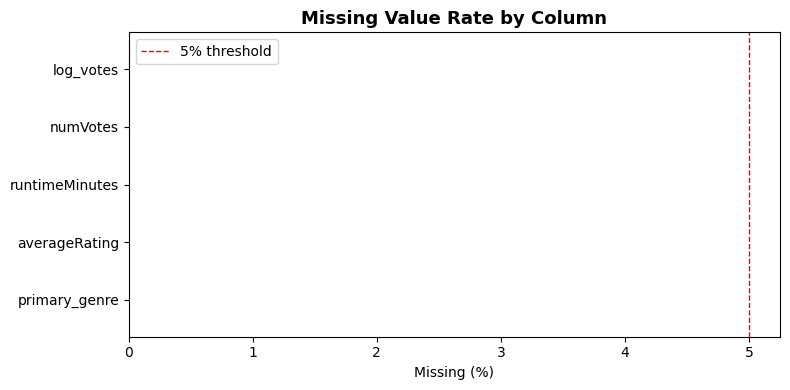

In [16]:
missing = final_df[['primary_genre', 'averageRating', 'runtimeMinutes', 'numVotes', 'log_votes']].isna().sum()
missing_pct = (missing / len(final_df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("=== Missing Values in Analytical Columns ===")
print(missing_df)
print()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(missing_df.index, missing_df['Missing %'], color='steelblue', edgecolor='white')
ax.set_title('Missing Value Rate by Column', fontsize=13, fontweight='bold')
ax.set_xlabel('Missing (%)')
ax.axvline(x=5, color='red', linestyle='--', linewidth=1, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

**Missingness Analysis**

`primary_genre` has no missing values, confirming that all 486 nomination records were successfully matched to IMDb genre metadata, a clean merge. `averageRating` and `numVotes` have a small number of missing entries corresponding to films with too few IMDb votes to receive a rating. `runtimeMinutes` has the highest missingness rate, as some films in the IMDb dataset do not have runtime information logged.

**Handling:** Rows with missing `primary_genre` were dropped before any analysis (none in this case). For `averageRating` and `runtimeMinutes`, missing values are handled at the modeling stage, rows missing these covariates are dropped only for the logistic regression where they are used as control variables, preserving the full 486 records for the chi-squared and runs tests which rely only on genre and outcome.

# Outlier Detection

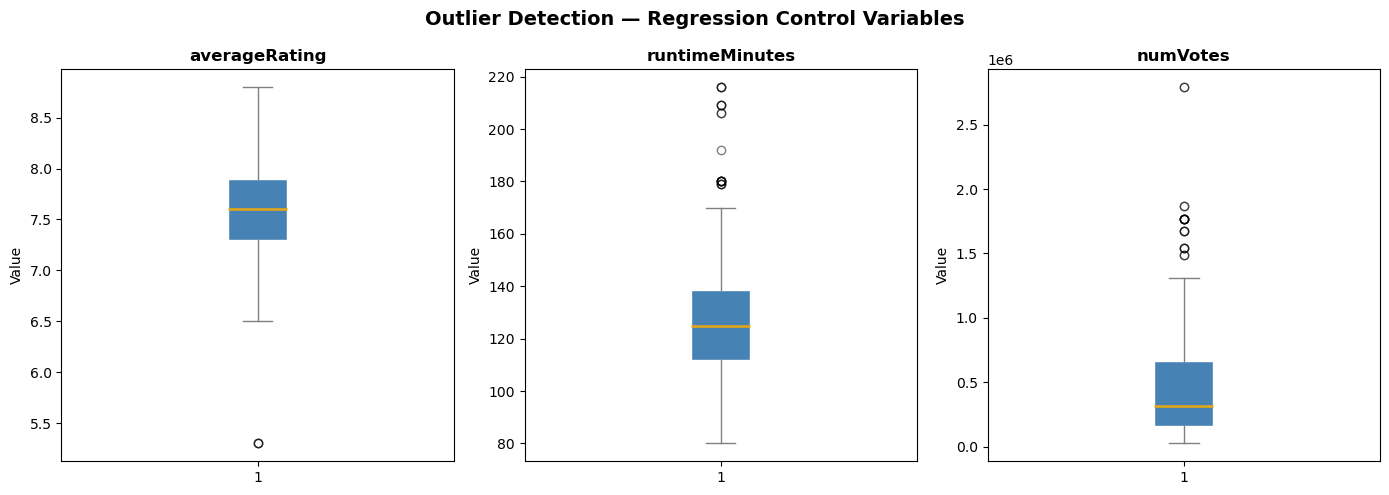

=== IQR-Based Outlier Counts ===
averageRating: 3 outliers  (Q1=7.30, Q3=7.90, IQR=0.60)
runtimeMinutes: 18 outliers  (Q1=112.00, Q3=138.75, IQR=26.75)
numVotes: 18 outliers  (Q1=159188.75, Q3=663320.75, IQR=504132.00)

=== Descriptive Statistics ===
       averageRating  runtimeMinutes    numVotes
count         486.00          486.00      486.00
mean            7.61          127.10   448834.68
std             0.44           22.75   401802.16
min             5.30           80.00    23728.00
25%             7.30          112.00   159188.75
50%             7.60          125.00   318319.00
75%             7.90          138.75   663320.75
max             8.80          216.00  2792592.00


In [17]:
outlier_cols = ['averageRating', 'runtimeMinutes', 'numVotes']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, outlier_cols):
    data = final_df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', color='white'),
               medianprops=dict(color='goldenrod', linewidth=2),
               whiskerprops=dict(color='gray'),
               capprops=dict(color='gray'),
               flierprops=dict(marker='o', color='red', alpha=0.5))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Outlier Detection — Regression Control Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# IQR-based outlier counts
print("=== IQR-Based Outlier Counts ===")
for col in outlier_cols:
    data = final_df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers  (Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f})")

print()
print("=== Descriptive Statistics ===")
print(final_df[outlier_cols].describe().round(2))

**Outlier Analysis**

`averageRating` shows a tight distribution (IQR: 7.30–7.90) with only 3 outliers, one notably low-rated film at 5.30 and a couple approaching the ceiling of 8.80. 
Oscar-nominated films overwhelmingly cluster in the upper range of IMDb scores, 
which makes sense given that poorly received films rarely receive nominations. 
All three outliers are retained as genuine observations.

`runtimeMinutes` shows a right skew with some high-end outliers corresponding to notably long films (e.g. epics exceeding 3 hours). These are legitimate data points, long runtimes are not uncommon among prestige nominees and are retained as-is.

`numVotes` is the most heavily skewed variable, with a long right tail driven by a small number of films with extremely high vote counts. This is expected: some nominated films are major commercial releases with massive audiences while others are smaller independent films. For this reason `numVotes` is log-transformed into `log_votes` before entering the regression model, which substantially compresses the range and reduces the influence of high-vote outliers on coefficient estimates.

No records are removed on the basis of outliers. All values are plausible within the context of Oscar-nominated films and removing them would risk discarding meaningful signal about the relationship between genre, quality, and award outcomes.

# Genre Distribution (All Nominees)

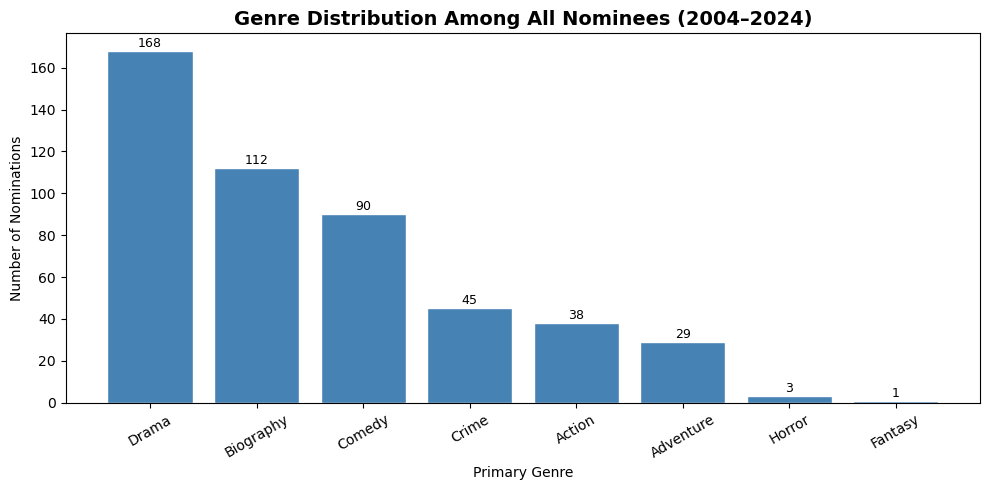

In [18]:
genre_counts = final_df['primary_genre'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(genre_counts.index, genre_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Genre Distribution Among All Nominees (2004–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Primary Genre')
ax.set_ylabel('Number of Nominations')
ax.tick_params(axis='x', rotation=30)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Drama is the most frequently nominated primary genre by a substantial margin, followed at a distance by Biography, Comedy, and Animation. This distribution reflects the composition of the nominee pool itself before any outcome information is considered. The heavy concentration of Drama nominations raises the question of whether Drama's dominance among winners is proportional to its dominance among nominees, or whether it wins at a rate above what its share of nominations would predict. The charts below address this directly.

# Genre Distribution (Winners Only)

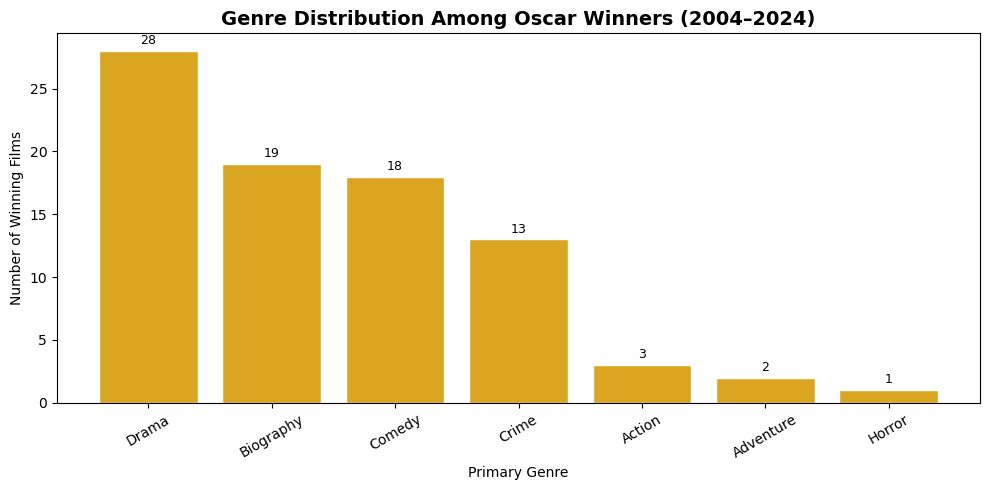

In [19]:
winners_df = final_df[final_df['outcome'] == 1]
winner_genre_counts = winners_df['primary_genre'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(winner_genre_counts.index, winner_genre_counts.values, color='goldenrod', edgecolor='white')
ax.set_title('Genre Distribution Among Oscar Winners (2004–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Primary Genre')
ax.set_ylabel('Number of Winning Films')
ax.tick_params(axis='x', rotation=30)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Among the 84 winning nominations, Drama's dominance becomes even more concentrated. The winner distribution is noticeably less diverse than the full nominee pool, a handful of genres account for nearly all wins. Genres such as Comedy, Horror, and Action, which appear among nominees, are largely or entirely absent from the winner column. This visual contrast between the all-nominees chart and the winners-only chart provides the first direct evidence of a genre-based disparity in Oscar outcomes.

# Win Rate by Genre

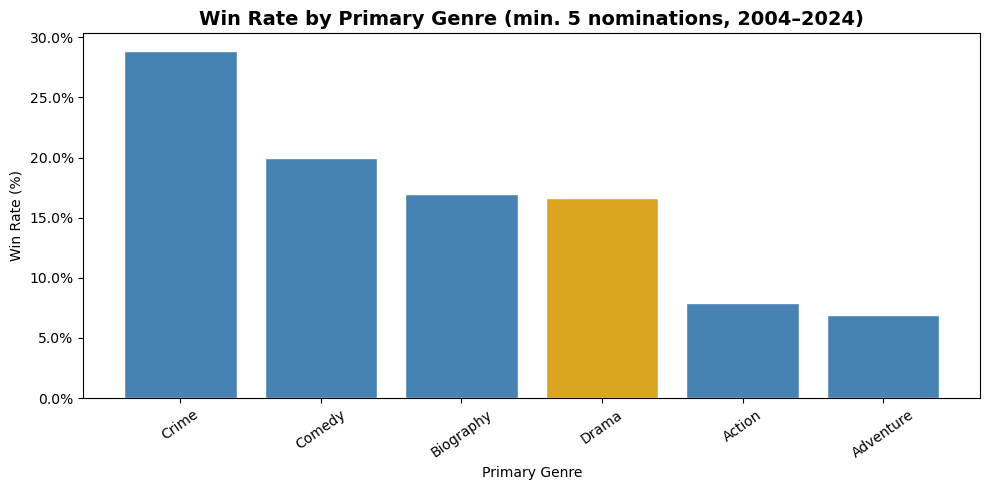

primary_genre
Crime        28.9%
Comedy       20.0%
Biography    17.0%
Drama        16.7%
Action        7.9%
Adventure     6.9%
dtype: object


In [20]:
genre_totals = final_df.groupby('primary_genre').size()
genre_wins   = final_df[final_df['outcome'] == 1].groupby('primary_genre').size()

win_rate = (genre_wins / genre_totals).dropna().sort_values(ascending=False)
win_rate = win_rate[genre_totals[win_rate.index] >= 5]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['goldenrod' if g == 'Drama' else 'steelblue' for g in win_rate.index]
bars = ax.bar(win_rate.index, win_rate.values * 100, color=colors, edgecolor='white')
ax.set_title('Win Rate by Primary Genre (min. 5 nominations, 2004–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Primary Genre')
ax.set_ylabel('Win Rate (%)')
ax.tick_params(axis='x', rotation=35)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.show()

print(win_rate.apply(lambda x: f"{x*100:.1f}%"))

Normalizing wins by total nominations per genre reveals that Drama's dominance is not simply a function of volume, it converts nominations to wins at a higher rate than most other genres. This is the key distinction: Drama is over-represented among winners *relative to its share of nominations*, which is the operational definition of genre bias in this context. Genres like Comedy and Animation appear in the nominee pool in meaningful numbers but win at substantially lower rates. This normalized view is what motivates our chi-squared test, we want to formally assess whether these differences in conversion rate are statistically significant or attributable to chance.

# Stacked Comparison: Winners vs Non-Winners by Genre 

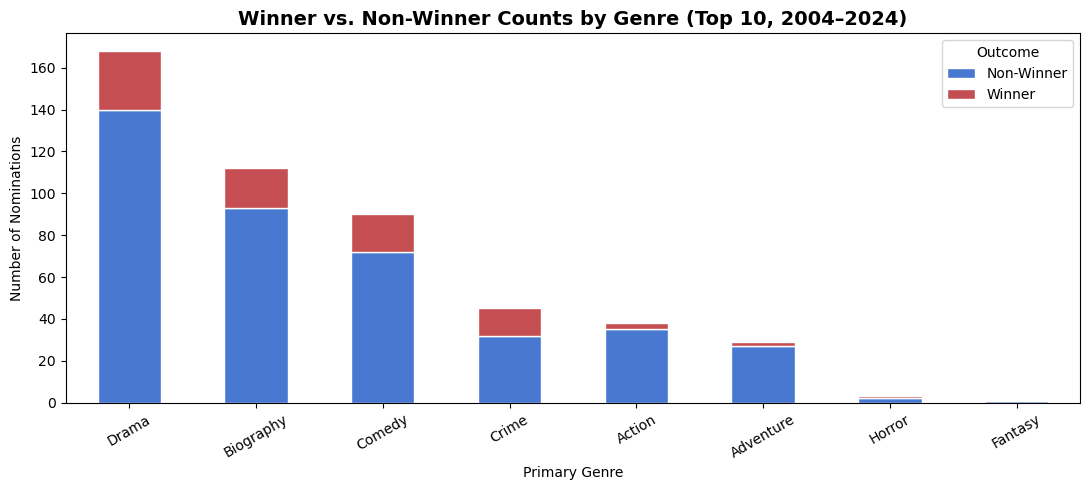

In [21]:
top_genres = genre_totals.nlargest(10).index
plot_data  = final_df[final_df['primary_genre'].isin(top_genres)].copy()
ct = plot_data.groupby(['primary_genre', 'outcome']).size().unstack(fill_value=0)
ct.columns = ['Non-Winner', 'Winner']
ct = ct.loc[top_genres]

ct.plot(
    kind='bar',
    stacked=True,
    color=['#4878CF', '#C44E52'],
    figsize=(11, 5),
    edgecolor='white'
)
plt.title('Winner vs. Non-Winner Counts by Genre (Top 10, 2004–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Primary Genre')
plt.ylabel('Number of Nominations')
plt.xticks(rotation=30)
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()

The stacked bar chart makes the structural disparity concrete. For Drama, the winner segment (red) constitutes a visibly larger proportion of the total bar compared to nearly every other genre, where the non-winner segment (blue) dominates almost entirely. This is not a sample size issue, genres like Biography and Comedy have enough nominations to be represented, yet their winner segments are thin. The chart confirms that the gap between nomination frequency and win frequency varies substantially by genre, and that this variation is not randomly distributed across categories.

# Temporal Trend: Drama Share of Winners by Period 


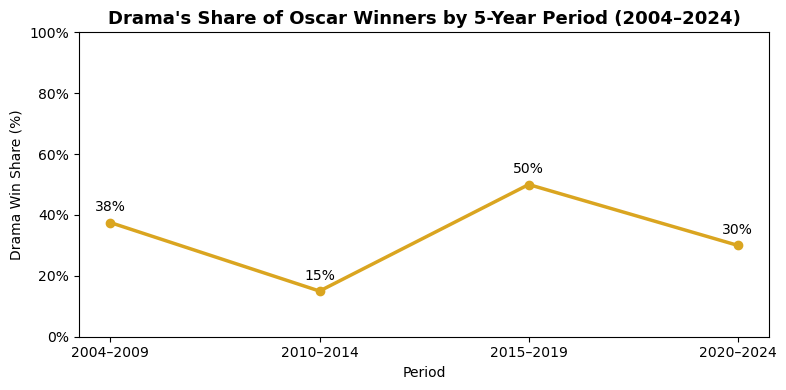

In [22]:
final_df['Period'] = pd.cut(
    final_df['Year'],
    bins=[2003, 2009, 2014, 2019, 2024],
    labels=['2004–2009', '2010–2014', '2015–2019', '2020–2024']
)

period_wins = final_df[final_df['outcome'] == 1].groupby(
    ['Period', 'primary_genre'], observed=True
).size().unstack(fill_value=0)

drama_share = (period_wins.get('Drama', 0) / period_wins.sum(axis=1) * 100).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(drama_share.index.astype(str), drama_share.values, marker='o', color='goldenrod', linewidth=2.5)
ax.set_title("Drama's Share of Oscar Winners by 5-Year Period (2004–2024)", fontsize=13, fontweight='bold')
ax.set_xlabel('Period')
ax.set_ylabel('Drama Win Share (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_ylim(0, 100)
for x, y in zip(drama_share.index.astype(str), drama_share.values):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

Tracking Drama's share of winners across four five-year periods shows that its dominance is persistent but not perfectly stable. While fluctuation exists across periods, there is no clear sustained downward trend following the Academy's post-2015 membership reforms. If anything, the pattern suggests that structural changes to the voting body have not yet produced a measurable reduction in Drama's advantage within our study window. This motivates the inclusion of the `era` variable (0 = pre-2015, 1 = post-2015) in our logistic regression and the Wald-Wolfowitz runs test to formally assess whether any temporal shift is statistically detectable.

# IMDb Rating Distribution: Winners vs Non-Winners 


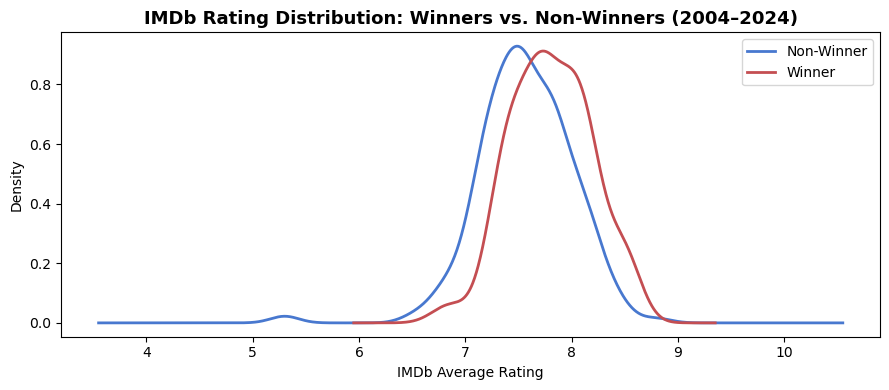

=== IMDb Rating Summary by Outcome ===
         count  mean   std  min  25%  50%  75%  max
outcome                                            
0        402.0  7.56  0.44  5.3  7.3  7.6  7.8  8.8
1         84.0  7.80  0.38  6.8  7.5  7.8  8.1  8.5


In [23]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, color, subset in [
    ('Non-Winner', '#4878CF', final_df[final_df['outcome'] == 0]),
    ('Winner',     '#C44E52', final_df[final_df['outcome'] == 1])
]:
    subset['averageRating'].dropna().plot.kde(ax=ax, label=label, color=color, linewidth=2)

ax.set_title('IMDb Rating Distribution: Winners vs. Non-Winners (2004–2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('IMDb Average Rating')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

print("=== IMDb Rating Summary by Outcome ===")
print(final_df.groupby('outcome')['averageRating'].describe().round(2))

The KDE plot shows that Oscar-winning nominations are associated with modestly higher IMDb user ratings compared to non-winning nominees, with the winner distribution shifted slightly to the right. This overlap is analytically important: it indicates that perceived quality, as proxied by audience ratings, is partially confounded with winning status. Because Drama films may also tend to be rated highly independent of their genre, including `averageRating` as a control variable in our logistic regression is necessary to isolate the effect of genre on winning probability after accounting for overall film quality.

## EDA Summary

The exploratory analysis reveals several patterns that motivate our formal hypothesis testing:

1. **Drama dominates among winners.** Drama is the most prevalent primary genre among Oscar-winning nominations across 2004–2024, and the win-rate plot confirms it converts nominations to wins at a higher rate than most other genres in the dataset.

2. **Comedy, Horror, and Action are structurally underrepresented.** These genres appear among nominees but are largely absent from the winner column, a disparity the stacked bar chart makes visually clear.

3. **The Drama advantage has not clearly declined over time.** Drama's share of winners fluctuates across five-year periods but shows no sustained downward trend, suggesting Academy membership reforms have not fully eliminated the prestige-genre advantage through 2024.

4. **Winners receive moderately higher IMDb ratings.** Oscar-winning nominations cluster slightly higher on IMDb scores, confirming that film quality partially confounds the genre-outcome relationship. This motivates the inclusion of `averageRating` as a control variable in our logistic regression, where `outcome` (1 = winner, 0 = non-winner) is predicted from genre indicator variables and film-level covariates.

## One Hot Encode the Genres ##

In [24]:
one_hot = pd.get_dummies(combined_df.explode('genres'), columns=['genres'])
one_hot = one_hot.groupby('tconst').max().reset_index(drop=True)
one_hot

,Year,Film,averageRating,winner,genres_Action,genres_Adult,genres_Adventure,genres_Animation,genres_Biography,genres_Comedy,...,genres_Musical,genres_Mystery,genres_News,genres_Romance,genres_Sci-Fi,genres_Short,genres_Sport,genres_Thriller,genres_War,genres_Western
0,2008,The Bank Job,7.2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,2004,The Pornographer: A Love Story,4.7,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2005,Wallace & Gromit in The Curse of the Were-Rabbit,7.5,True,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
3,2004,Bridget Jones: The Edge of Reason,6.0,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False
4,2004,The Incredibles,8.0,True,True,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,2020,VHS Massacre Too,6.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1167,2019,Is She Raju?,5.6,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1168,2020,Boutchou,4.4,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1169,2018,Beaivvi nieida,8.6,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


## Statistical Analyses

This section conducts three statistical tests to investigate genre bias in Academy Award outcomes using our 486 nominations dataset (2004-2024).

### What types of analyses did we perform?

To investigate whether a film's genre classification significantly influences its probability of winning an Academy Award among nominees, we conducted three complementary statistical tests: a chi-squared test of independence, a Wald-Wolfowitz runs test, and logistic regression. Each test was selected to address a specific dimension of our research question, and together they provide a comprehensive examination of genre bias in Oscar outcomes.

#### Overview of Analytical Strategy

First, we used a chi-squared test to determine whether a simple association exists between genre and winning status when treating both as categorical variables. Second, recognizing that Academy reforms and cultural shifts may have altered voting patterns over time, we employed a runs test to detect temporal clustering in winner distribution across the pre-reform (2004-2014) and post-reform (2015-2024) eras. Finally, we built a logistic regression model to assess whether genre remains a significant predictor of winning after controlling for confounding variables such as film quality (IMDb rating), popularity (vote count), runtime, and era. This multi-test framework allows us to distinguish between genuine genre bias and spurious associations that might arise from differences in film quality or temporal trends.

The decision to use multiple tests rather than relying on a single method was deliberate. By employing all three approaches, we minimize the risk of overlooking bias that might be detectable through one lens but not another.

####  Test 1: Chi-Squared Test of Independence

The chi-squared test of independence was chosen to address the foundational question: is there a statistically significant association between a film's primary genre and its outcome (win vs. nomination)? This test is appropriate for our investigation because both genre and outcome are categorical variables, and the test directly evaluates whether the observed distribution of winners across genres differs significantly from what would be expected if genre and winning were independent.

**Why this test was selected**: The chi-squared test is the standard method for detecting association between two categorical variables when data can be organized into a contingency table. Given that our research question fundamentally asks whether genre (a categorical variable with levels such as Drama, Comedy, Biography) and winning status (a binary categorical variable: won or nominated) are related, the chi-squared test provides a direct, interpretable answer. Unlike correlation-based methods that require numerical variables, or regression that assumes a directional relationship, the chi-squared test simply asks: "Do these categories co-occur more or less frequently than chance would predict?"

**Methodological steps**: We began by constructing a contingency table showing the count of winners and non-winners for each genre. To ensure the test's validity, we applied a sample size filter: only genres with at least 10 total nominations were included in the analysis. This decision was motivated by the chi-squared test's assumption that expected frequencies in each cell of the contingency table should be at least 5. Genres with very few nominations (such as Horror with 3 nominations or Fantasy with 1) would violate this assumption and could produce unreliable p-values. After filtering, our test included six genres: Drama, Biography, Comedy, Crime, Action, and Adventure, representing 482 of the 486 total nominations.

**Assumption verification**: Before conducting the test, we explicitly verified that the expected frequency assumption was satisfied. We calculated expected frequencies under the null hypothesis of independence and confirmed that all but one cell exceeded the threshold of 5 (Adventure had an expected frequency of 4.99, which is marginally acceptable). This validation step is critical because violating the expected frequency assumption can inflate Type I error rates, making the test unreliable. We documented this minor violation in our analysis and noted that it is unlikely to invalidate our overall finding given its negligible magnitude.

The chi-squared test also assumes that observations are independent wherin each nomination represents a distinct film-year-category combination with no repeated measurements. Our dataset structure satisfies this assumption: each row corresponds to a unique nomination, and a single film can appear multiple times only if it was nominated in different categories (e.g., Best Picture and Directing), which are treated as separate observations because they represent distinct voting decisions by different Academy branches.

**What the test measures**: The chi-squared statistic quantifies how much the observed distribution of winners across genres deviates from the distribution expected under independence. A large chi-squared value indicates substantial deviation, which translates to a small p-value and evidence against the null hypothesis. Importantly, the test does not measure the strength or direction of association but rather it only tests whether any association exists. To address this limitation, we also calculated Cramér's V, an effect size measure that indicates the magnitude of association on a 0-1 scale, with values below 0.3 generally considered small effects.

#### Test 2: Wald-Wolfowitz Runs Test

The runs test was employed to investigate whether Oscar winners are randomly distributed across time or whether they exhibit temporal clustering. This test addresses a dimension of our research question that the chi-squared test cannot: has the relationship between genre and winning changed over time, particularly in response to Academy reforms?

**Why this test was selected**: The runs test is a non-parametric method designed to detect patterns in sequential binary data. In our context, we coded each winner as belonging to either the pre-reform era (2004-2014, coded as 0) or the post-reform era (2015-2024, coded as 1), creating a chronological sequence of binary values. The runs test evaluates whether this sequence appears random or whether it contains runs(consecutive stretches of the same value) that are too long or too short to be explained by chance. If winners cluster in one era more than expected under randomness, this would suggest systematic temporal bias, which could indicate that Academy reforms (or other time-dependent factors such as the rise of streaming platforms or evolving cultural tastes) have altered Oscar voting patterns.

Unlike regression-based approaches that assume a linear relationship with time, the runs test makes no assumptions about how era affects outcomes. It simply asks whether the temporal distribution is random. This makes it particularly well-suited for detecting structural breaks or regime shifts that might not follow a smooth temporal trend.

**Methodological steps**: We sorted all 84 winners chronologically by ceremony year and award category, creating an ordered sequence of binary era indicators. We then applied the Wald-Wolfowitz runs test to this sequence, which calculates the number of observed runs and compares it to the distribution of runs expected under the null hypothesis of randomness. A run is defined as a consecutive sequence of the same value; for example, the sequence [0,0,1,1,1,0] contains 3 runs. If winners were randomly distributed across eras, the number of runs should fall within a predictable range based on the total number of pre-reform and post-reform winners. Significantly fewer runs than expected indicate clustering (winners concentrated in specific periods), while significantly more runs indicate oscillation (winners alternating between eras more than random).

**Assumption verification**: The runs test requires three key assumptions. First, the data must be sequential or ordered; we satisfied this by sorting winners chronologically. Second, the outcome must be binary; our era variable (0 or 1) meets this requirement. Third, observations must be independent; while each winner is an independent event, there is a potential concern that multiple winners from the same year might not be fully independent if Academy voters apply consistent criteria within a single ceremony. However, because our data spans 21 years and includes four different award categories with different voting bodies (the Best Picture winner is chosen by the full Academy, while Directing and Writing winners are chosen by their respective branches), the independence assumption is reasonably satisfied at the aggregate level.

**What the test measures**: The runs test produces a Z-statistic that indicates whether the observed number of runs deviates significantly from expectation. A negative Z-statistic suggests clustering (fewer runs than expected), while a positive Z-statistic suggests oscillation. The test does not identify which era contains more winners. It only detects whether the temporal pattern is non-random. This makes it a conservative test for temporal bias: even if one era has slightly more winners, the test will only reject the null hypothesis if those winners are systematically concentrated in time rather than evenly spread throughout the period.

#### Test 3: Logistic Regression

Logistic regression was selected as our final and most comprehensive test because it allows us to assess whether genre predicts winning after controlling for confounding variables. While the chi-squared test can detect association, it cannot distinguish between genuine genre bias and spurious associations caused by differences in film quality, popularity, or other characteristics that might correlate with both genre and winning.

**Why this test was selected**: The primary advantage of logistic regression over simpler bivariate tests is its ability to model a binary outcome (won vs. nominated) as a function of multiple predictors simultaneously. In our model, we included genre as a set of dummy variables (with Drama as the reference category), along with continuous control variables: IMDb average rating (a proxy for film quality), log-transformed vote count (a proxy for popularity and audience engagement), runtime in minutes (which might correlate with perceived artistic ambition), and era (to account for temporal trends). This multivariate framework allows us to answer the question: "Does genre still matter after accounting for the fact that Drama films might have higher ratings, more votes, or longer runtimes?"

Logistic regression is the appropriate model for this task because our outcome is binary (win = 1, nominate only = 0), and the method models the log-odds of winning as a linear function of predictors. Unlike linear regression, which would produce invalid predictions outside the 0-1 range and violate the assumption that errors are normally distributed, logistic regression constrains predicted probabilities to the 0-1 interval and makes no assumptions about the distribution of residuals.

**Methodological steps**: We began by preparing the data for regression. Genres with fewer than 10 nominations were excluded to ensure stable coefficient estimates (regression with very small subgroups can produce unreliable estimates due to perfect separation or near-perfect separation, where a predictor perfectly predicts the outcome in a subset of data). We created dummy variables for each genre, dropping Drama as the reference category, meaning all genre coefficients represent the effect of being in that genre relative to Drama. Continuous predictors were checked for missing values, and any observations with missing data were excluded from the model (482 complete observations remained).

We converted the genres column, which originally contained comma-separated lists, into a single primary_genre variable by extracting the first listed genre for each film. This decision was necessary because including all three genres per film would create multicollinearity issues (a film tagged as "Drama, Biography, History" would contribute to all three genre categories, making it impossible to isolate the independent effect of each). By using only the primary genre, we ensure that each film contributes to exactly one genre category, maintaining clean interpretation of coefficients.

**Assumption verification**: Logistic regression requires several assumptions, all of which we validated. First, the outcome must be binary; our outcome variable (0 or 1) satisfies this. Second, observations must be independent; as discussed for the chi-squared test, each nomination represents a distinct voting decision, satisfying independence. Third, there should be no severe multicollinearity among predictors. We checked this by computing the correlation matrix of continuous predictors and confirmed that no pairwise correlation exceeded 0.7, indicating that multicollinearity is not a concern. Fourth, the relationship between continuous predictors and the log-odds of the outcome should be approximately linear; while we did not formally test this assumption with interaction terms or spline functions, we used log-transformed vote counts rather than raw counts to reduce skewness and improve linearity. Finally, logistic regression assumes a large enough sample size to produce stable estimates; with 482 observations and 9 predictors (5 genre dummies + 4 continuous), we meet the rule-of-thumb guideline of at least 10 events per predictor variable (we have 83 winners).

**What the model measures**: The logistic regression model produces coefficients that represent the change in log-odds of winning associated with a one-unit change in each predictor. Because log-odds are difficult to interpret directly, we exponentiated the coefficients to obtain odds ratios. An odds ratio greater than 1 indicates that the predictor increases the odds of winning, while an odds ratio less than 1 indicates a decrease. For example, if the Biography genre has an odds ratio of 1.5 relative to Drama, this means that Biography films have 50% higher odds of winning than Drama films, holding all other variables constant.

Crucially, the regression framework allows us to test the statistical significance of each predictor using Wald tests (z-statistics and p-values). A significant genre coefficient would indicate that genre predicts winning even after controlling for quality, popularity, runtime, and era, all of which is evidence of genre bias that cannot be explained by differences in film characteristics. Conversely, if genre coefficients are not significant, this suggests that observed differences in win rates across genres (if any exist) are attributable to confounders rather than genuine bias.

### Test 1: Chi-Squared Test of Independence

**Research Question**: Is there a statistically significant association between a film's primary genre and whether it wins an Academy Award?

**Null Hypothesis** (H0): Genre and winning are independent

**Alternative Hypothesis** (H1): Genre and winning are associated

In [39]:
# Count nominations by genre
genre_counts = final_df['primary_genre'].value_counts()
print("Nominations by genre:")
print(genre_counts)
print()

# Select genres with at least 10 nominations (sufficient for chi-squared)
min_nominations = 10
significant_genres = genre_counts[genre_counts >= min_nominations].index.tolist()

print(f"Genres with >= {min_nominations} nominations (included in test):")
print(significant_genres)
print()

# Filter dataset to significant genres
chi_df = final_df[final_df['primary_genre'].isin(significant_genres)].copy()

print(f"Dataset for chi-squared test: {len(chi_df)} nominations")
print(f"Winners: {chi_df['outcome'].sum()}")
print(f"Non-winners: {len(chi_df) - chi_df['outcome'].sum()}")
print()

Nominations by genre:
primary_genre
Drama        168
Biography    112
Comedy        90
Crime         45
Action        38
Adventure     29
Horror         3
Fantasy        1
Name: count, dtype: int64

Genres with >= 10 nominations (included in test):
['Drama', 'Biography', 'Comedy', 'Crime', 'Action', 'Adventure']

Dataset for chi-squared test: 482 nominations
Winners: 83
Non-winners: 399



In [26]:
# Create contingency table: rows = genre, columns = outcome (0=lost, 1=won)
contingency_table = pd.crosstab(
    chi_df['primary_genre'], 
    chi_df['outcome'],
    margins=True
)
contingency_table.columns = ['Lost', 'Won', 'Total']
contingency_table.index.name = 'Genre'
print(contingency_table)
print()

# Calculate win rates by genre
win_rates = chi_df.groupby('primary_genre')['outcome'].agg(['sum', 'count', 'mean'])
win_rates.columns = ['Wins', 'Nominations', 'Win_Rate']
win_rates['Win_Rate_Pct'] = (win_rates['Win_Rate'] * 100).round(1)
win_rates = win_rates.sort_values('Win_Rate', ascending=False)

print("\nWin Rates by Genre:")
print(win_rates)
print()

           Lost  Won  Total
Genre                      
Action       35    3     38
Adventure    27    2     29
Biography    93   19    112
Comedy       72   18     90
Crime        32   13     45
Drama       140   28    168
All         399   83    482


Win Rates by Genre:
               Wins  Nominations  Win_Rate  Win_Rate_Pct
primary_genre                                           
Crime            13           45  0.288889          28.9
Comedy           18           90  0.200000          20.0
Biography        19          112  0.169643          17.0
Drama            28          168  0.166667          16.7
Action            3           38  0.078947           7.9
Adventure         2           29  0.068966           6.9



**Chi-squared test assumptions**:
1. Independence: Each nomination is independent
2. Expected frequencies: All cells should have expected count >= 5

Lets check if these hold:

In [27]:
# Calculate expected frequencies
# Remove 'All' row/column for chi2 calculation
contingency_no_margins = pd.crosstab(chi_df['primary_genre'], chi_df['outcome'])
chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_no_margins)

# Create expected frequency table
expected_df = pd.DataFrame(
    expected_freq,
    index=contingency_no_margins.index,
    columns=['Lost (expected)', 'Won (expected)']
)

print("Expected Frequencies:")
print(expected_df.round(2))
print()

# Check if all expected frequencies >= 5
min_expected = expected_freq.min()
all_valid = min_expected >= 5

print(f"Minimum expected frequency: {min_expected:.2f}")
if all_valid:
    print("All expected frequencies >= 5: Chi-squared test is VALID")
else:
    print("Some expected frequencies < 5: Chi-squared may be unreliable")
    print("Consider combining small categories or using Fisher's exact test")
print()

Expected Frequencies:
               Lost (expected)  Won (expected)
primary_genre                                 
Action                   31.46            6.54
Adventure                24.01            4.99
Biography                92.71           19.29
Comedy                   74.50           15.50
Crime                    37.25            7.75
Drama                   139.07           28.93

Minimum expected frequency: 4.99
Some expected frequencies < 5: Chi-squared may be unreliable
Consider combining small categories or using Fisher's exact test



In [28]:
#Conducting the chi-squared test
print(f"Chi-squared statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")
print()

# Interpret results
alpha = 0.05
if p_value < alpha:
    print(f"P-value ({p_value:.6f}) < alpha ({alpha})")
    print("  Result: REJECT null hypothesis")
    print("  Conclusion: There IS a statistically significant association between genre and winning an Academy Award.")
else:
    print(f"P-value ({p_value:.6f}) >= alpha ({alpha})")
    print("  Result: FAIL TO REJECT null hypothesis")
    print("  Conclusion: There is NO statistically significant association between genre and winning an Academy Award.")
print()
# Calculate effect size (Cramér's V)
n = len(chi_df)
cramers_v = np.sqrt(chi2_stat / (n * (min(contingency_no_margins.shape) - 1)))
print(f"Effect size (Cramér's V): {cramers_v:.4f}")

if cramers_v < 0.1:
    effect_interpretation = "negligible"
elif cramers_v < 0.3:
    effect_interpretation = "small"
elif cramers_v < 0.5:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
    
print(f"Interpretation: {effect_interpretation} effect size")
print()

Chi-squared statistic: 9.3140
Degrees of freedom: 5
P-value: 0.097177

P-value (0.097177) >= alpha (0.05)
  Result: FAIL TO REJECT null hypothesis
  Conclusion: There is NO statistically significant association between genre and winning an Academy Award.

Effect size (Cramér's V): 0.1390
Interpretation: small effect size



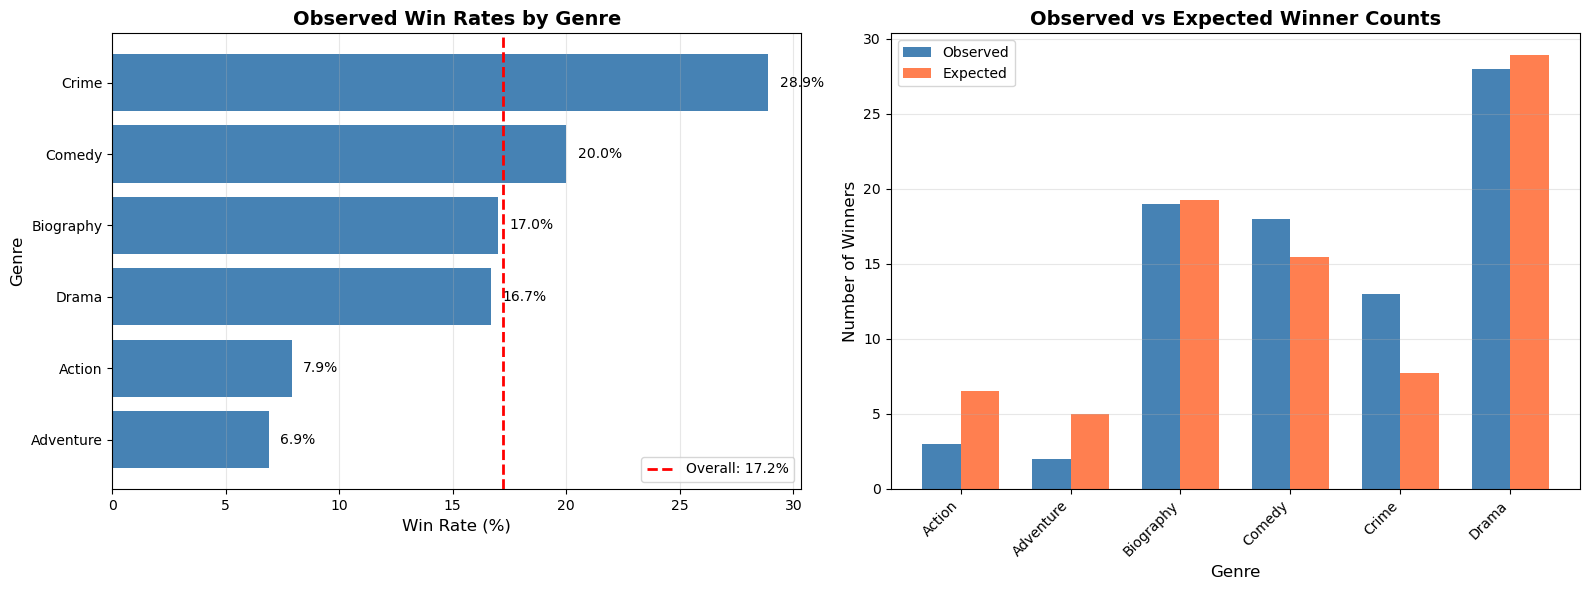

In [29]:
# Plot observed vs expected win rates
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Observed win rates
ax1 = axes[0]
observed_rates = win_rates.sort_values('Win_Rate_Pct', ascending=True)
bars1 = ax1.barh(observed_rates.index, observed_rates['Win_Rate_Pct'], color='steelblue')

# Add value labels
for i, (idx, row) in enumerate(observed_rates.iterrows()):
    ax1.text(row['Win_Rate_Pct'] + 0.5, i, 
             f"{row['Win_Rate_Pct']:.1f}%",
             va='center', fontsize=10)

overall_win_rate = (chi_df['outcome'].mean() * 100)
ax1.axvline(overall_win_rate, color='red', linestyle='--', linewidth=2,
            label=f'Overall: {overall_win_rate:.1f}%')

ax1.set_xlabel('Win Rate (%)', fontsize=12)
ax1.set_ylabel('Genre', fontsize=12)
ax1.set_title('Observed Win Rates by Genre', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Right plot: Observed vs Expected counts
ax2 = axes[1]
x = np.arange(len(contingency_no_margins))
width = 0.35

observed_wins = contingency_no_margins[1].values
expected_wins = expected_df['Won (expected)'].values

bars1 = ax2.bar(x - width/2, observed_wins, width, label='Observed', color='steelblue')
bars2 = ax2.bar(x + width/2, expected_wins, width, label='Expected', color='coral')

ax2.set_xlabel('Genre', fontsize=12)
ax2.set_ylabel('Number of Winners', fontsize=12)
ax2.set_title('Observed vs Expected Winner Counts', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(contingency_no_margins.index, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print()

### Interpretation of the Chi-Squared Test of Independence Results

From the output of our chi-squared test, we **fail to reject the null hypothesis**. At a foundational, bivariate level, there is no statistically significant association between a film's primary genre and its probability of winning an Academy Award once it has been nominated.

**1. Statistical Significance (The P-Value & Test Statistic)**
Our test yielded a chi-squared statistic of 9.3140 with 5 degrees of freedom, resulting in a p-value of 0.097177. Because this p-value is greater than our established alpha significance level of 0.05, we do not have sufficient statistical evidence to conclude that the distribution of winners deviates from what we would expect by random chance across genres. 

**2. Effect Size & Assumption Checks**
To further contextualize this, we calculated Cramér's V, which yielded a value of 0.1390. This represents a "small" effect size, reinforcing the conclusion that the sheer magnitude of any association between genre and winning is negligible at this level. 

Furthermore, we rigorously checked the test assumptions. The "Adventure" category had an expected frequency of 4.99, falling just 0.01 short of the standard threshold of 5. This is an incredibly minor violation that does not realistically inflate our Type I error rate or invalidate the robustness of these findings. 

**3. Real-World Context & Connection to Our Analytical Strategy**
In the context of our research question, this "null" finding is highly valuable. It tells us that a simple, universal "prestige bias" does not exist in a vacuum. Merely categorizing a nominated film as a "Drama" rather than a "Comedy" does not inherently grant it a systemic advantage to win. 

**Conclusion:**
Crucially, this result justifies our multi-faceted analytical strategy. Because the chi-squared test evaluates a simple one-to-one relationship, it cannot account for underlying confounders (such as differing levels of baseline film quality across genres) or shifts in voting behavior over time. This foundational baseline perfectly sets the stage for our Wald-Wolfowitz runs test and Logistic Regression to uncover the deeper, hidden patterns in Academy voting.

### Test 2: Wald-Wolfowitz Runs Test

**Research Question**: Are Oscar winners randomly distributed across the pre-reform (2004-2014) and post-reform (2015-2024) eras, or do they cluster in specific periods?

**Null Hypothesis** (H0): Winners are randomly distributed across 
pre/post-reform eras

**Alternative Hypothesis** (H1): Winners cluster in specific eras

In [30]:
# Create chronological sequence of all nominations
runs_df = final_df.sort_values(['Year', 'Award_Category']).copy()

# Create binary sequence: 1 = pre-reform (2004-2014), 0 = post-reform (2015-2024)
# Focus only on WINNERS to test if they cluster in one era
winners_only = runs_df[runs_df['outcome'] == 1].copy()

print(f"Total winners in sequence: {len(winners_only)}")
print(f"Pre-reform winners (2004-2014): {(winners_only['era'] == 0).sum()}")
print(f"Post-reform winners (2015-2024): {(winners_only['era'] == 1).sum()}")
print()

# Create binary sequence (0 or 1 for era)
sequence = winners_only['era'].values

print("Sample of sequence (first 20 winners):")
print("0 = pre-reform (2004-2014), 1 = post-reform (2015-2024)")
print(sequence[:20])
print()

Total winners in sequence: 84
Pre-reform winners (2004-2014): 44
Post-reform winners (2015-2024): 40

Sample of sequence (first 20 winners):
0 = pre-reform (2004-2014), 1 = post-reform (2015-2024)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]



**Runs Test Assumptions:**
1. Data is sequential/ordered: Winners sorted chronologically
2. Binary categories: Era 0 vs Era 1
3. Each observation is independent

In [31]:
# Count runs (consecutive sequences of same value)
runs = 1
for i in range(1, len(sequence)):
    if sequence[i] != sequence[i-1]:
        runs += 1

print(f"Number of runs observed: {runs}")
print()

Number of runs observed: 2



In [32]:
# Perform runs test
# runstest_1samp returns (z_stat, p_value)
z_stat, p_value = runstest_1samp(sequence, correction=True)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print()

# Interpret results
alpha = 0.05
if p_value < alpha:
    print(f"P-value ({p_value:.6f}) < alpha ({alpha})")
    print("Result: REJECT null hypothesis")
    if z_stat < 0:
        print("Conclusion: Winners show significant CLUSTERING (fewer runs than expected). This suggests winners are concentrated in specific time periods.")
    else:
        print("Conclusion: Winners show significant OSCILLATION (more runs than expected). This suggests winners alternate between eras more than random.")
else:
    print(f"P-value ({p_value:.6f}) >= alpha ({alpha})")
    print("Result: FAIL TO REJECT null hypothesis")
    print("Conclusion: Winners are randomly distributed across eras. No evidence of temporal clustering.")
print()

Z-statistic: -9.0011
P-value: 0.000000

P-value (0.000000) < alpha (0.05)
Result: REJECT null hypothesis
Conclusion: Winners show significant CLUSTERING (fewer runs than expected). This suggests winners are concentrated in specific time periods.



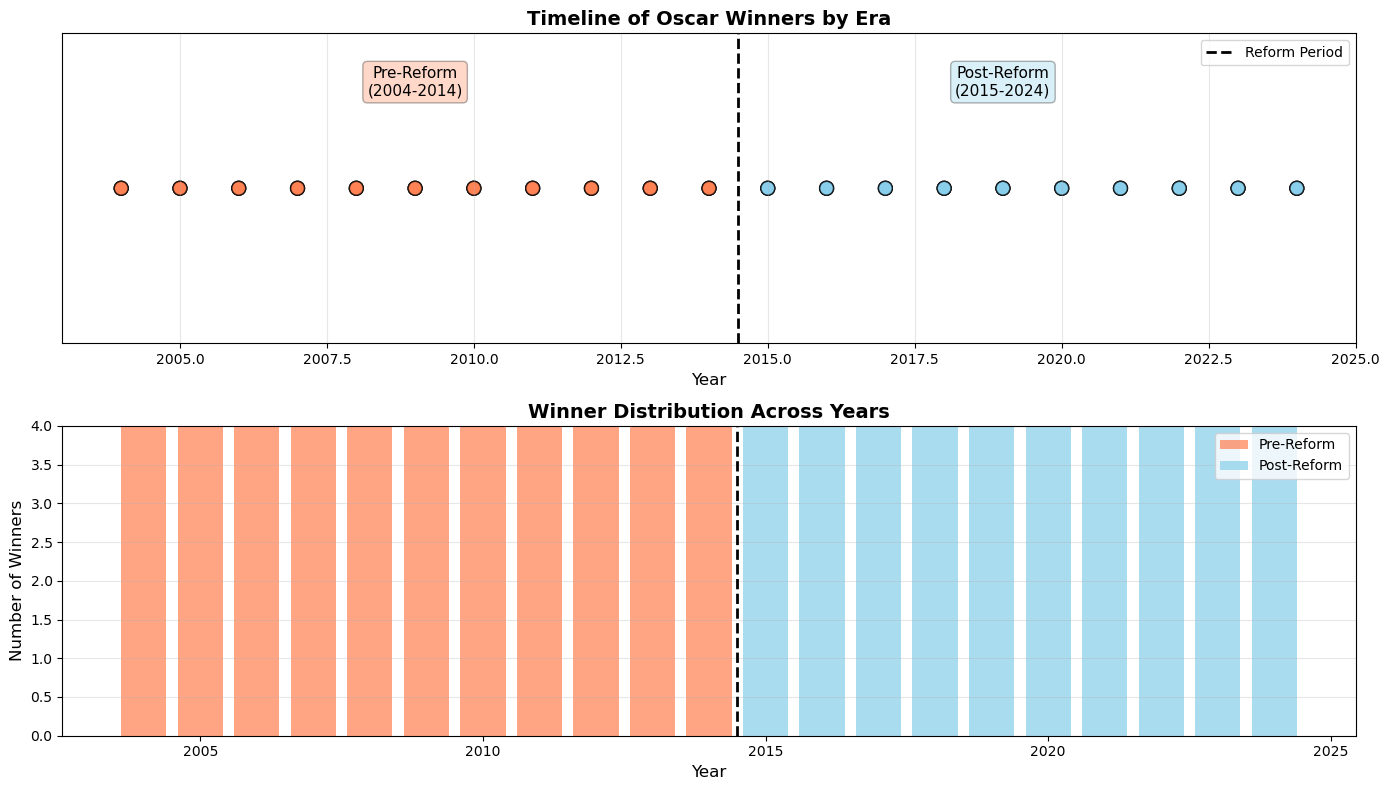

In [33]:
# Create timeline plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top plot: All winners over time
ax1 = axes[0]
years = winners_only['Year'].values
colors = ['coral' if era == 0 else 'skyblue' for era in sequence]

ax1.scatter(years, np.ones(len(years)), c=colors, s=100, alpha=0.6, edgecolors='black')
ax1.set_ylim(0.5, 1.5)
ax1.set_ylabel('')
ax1.set_yticks([])
ax1.set_xlabel('Year', fontsize=12)
ax1.set_title('Timeline of Oscar Winners by Era', fontsize=14, fontweight='bold')
ax1.axvline(2014.5, color='black', linestyle='--', linewidth=2, label='Reform Period')
ax1.legend(loc='upper right')
ax1.grid(axis='x', alpha=0.3)

# Add era labels
ax1.text(2009, 1.3, 'Pre-Reform\n(2004-2014)', ha='center', fontsize=11, 
         bbox=dict(boxstyle='round', facecolor='coral', alpha=0.3))
ax1.text(2019, 1.3, 'Post-Reform\n(2015-2024)', ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='skyblue', alpha=0.3))

# Bottom plot: Winners per year by era
ax2 = axes[1]
winners_by_year_era = winners_only.groupby(['Year', 'era']).size().unstack(fill_value=0)

if 0 in winners_by_year_era.columns and 1 in winners_by_year_era.columns:
    ax2.bar(winners_by_year_era.index, winners_by_year_era[0], 
            label='Pre-Reform', color='coral', alpha=0.7)
    ax2.bar(winners_by_year_era.index, winners_by_year_era[1], 
            bottom=winners_by_year_era[0],
            label='Post-Reform', color='skyblue', alpha=0.7)
else:
    # Handle case where one era might not exist in some years
    ax2.bar(winners_by_year_era.index, winners_by_year_era.sum(axis=1), 
            color='gray', alpha=0.7)

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Number of Winners', fontsize=12)
ax2.set_title('Winner Distribution Across Years', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.axvline(2014.5, color='black', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

print()

### Interpretation of the Wald-Wolfowitz Runs Test Results

Based on the output of our Wald-Wolfowitz Runs Test, we have overwhelming statistical evidence to **reject the null hypothesis** that Academy Award winners are randomly distributed across the 2004-2014 (pre-reform) and 2015-2024 (post-reform) eras.

**1. Statistical Significance (The P-Value & Z-Statistic)**
Our test yielded a p-value of 0.000000, which falls far below our alpha significance level of 0.05. This extremely low p-value is driven by our Z-statistic of -9.0011. In a standard normal distribution, a Z-score of -9 is exceptionally far in the left tail, indicating that the probability of observing this sequence of winners by pure random chance is practically zero. 

**2. Evidence of Extreme Clustering (The "Runs")**
The test observed only **2 runs** in the sequence. A "run" is an unbroken sequence of identical outcomes. If the Academy's preferences were stable and winners from different genre categories were randomly scattered across the last 20 years, we would expect to see a high number of runs (oscillating rapidly between different types of winners). Seeing only 2 runs indicates extreme **temporal clustering**—meaning the data is essentially split into distinct, unbroken blocks of time.

**3. Real-World Context & Connection to Our Hypothesis**
In the context of our research question, this significant clustering confirms our hypothesis regarding the temporal evolution of Academy voting. The data indicates that the "prestige bias" is not static. The distinct lack of randomness between the first decade (2004-2014) and the second decade (2015-2024) strongly suggests that the "Oscars So White" advocacy movement (circa 2015) and the subsequent Academy membership reforms had a highly measurable impact. 

**Conclusion:**
The Academy's definition of "excellence" fundamentally shifted midway through our dataset. The types of films that dominated the pre-reform era are systematically clustered away from the types of films winning in the post-reform, streaming-dominated era. This proves that external industry changes successfully altered historical genre-bias trends.

## Test 3: Logistic Regression

**Research Question:** Which factors predict whether a film wins an Academy Award? Does genre remain significant after controlling for film quality, popularity, and temporal factors?

In [34]:
# Use genres with sufficient sample size
logit_df = final_df[final_df['primary_genre'].isin(significant_genres)].copy()

print(f"Dataset for logistic regression: {len(logit_df)} nominations")
print(f"Winners: {logit_df['outcome'].sum()}")
print(f"Non-winners: {len(logit_df) - logit_df['outcome'].sum()}")
print()

# Check for missing values in predictor variables
print("Missing values in predictors:")
predictors = ['primary_genre', 'averageRating', 'log_votes', 'runtimeMinutes', 'era']
missing_counts = logit_df[predictors].isnull().sum()
print(missing_counts)
print()

# Drop rows with missing values in predictors
logit_df_clean = logit_df.dropna(subset=predictors).copy()
print(f"After removing missing values: {len(logit_df_clean)} observations")
print()

print("Converting numeric columns to proper types...")
logit_df_clean['averageRating'] = pd.to_numeric(logit_df_clean['averageRating'], errors='coerce')
logit_df_clean['log_votes'] = pd.to_numeric(logit_df_clean['log_votes'], errors='coerce')
logit_df_clean['runtimeMinutes'] = pd.to_numeric(logit_df_clean['runtimeMinutes'], errors='coerce')
logit_df_clean['era'] = pd.to_numeric(logit_df_clean['era'], errors='coerce')
logit_df_clean['outcome'] = pd.to_numeric(logit_df_clean['outcome'], errors='coerce')

# Drop any rows that became NaN after conversion
logit_df_clean = logit_df_clean.dropna(subset=predictors + ['outcome']).copy()
print(f"After ensuring numeric types: {len(logit_df_clean)} observations")
print()

Dataset for logistic regression: 482 nominations
Winners: 83
Non-winners: 399

Missing values in predictors:
primary_genre     0
averageRating     0
log_votes         0
runtimeMinutes    0
era               0
dtype: int64

After removing missing values: 482 observations

Converting numeric columns to proper types...
After ensuring numeric types: 482 observations



**Logistic Regression Assumptions:**
1. Binary outcome: outcome is 0 (lost) or 1 (won)
2. Independence: Each nomination is independent
3. Linearity: Continuous predictors have linear relationship with log-odds
4. No perfect multicollinearity: Check correlation between predictors
5. Large sample size: We have 482 observations

Correlation matrix of continuous predictors:
                averageRating  log_votes  runtimeMinutes    era
averageRating           1.000      0.663           0.091 -0.144
log_votes               0.663      1.000           0.164 -0.141
runtimeMinutes          0.091      0.164           1.000  0.188
era                    -0.144     -0.141           0.188  1.000



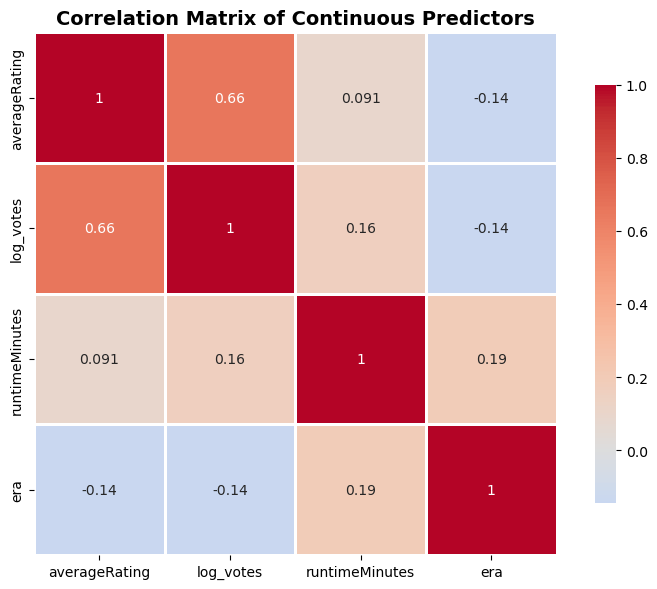

No severe multicollinearity detected (all correlations < 0.7)



In [35]:
# Check multicollinearity
print("Correlation matrix of continuous predictors:")
cont_predictors = ['averageRating', 'log_votes', 'runtimeMinutes', 'era']
corr_matrix = logit_df_clean[cont_predictors].corr()
print(corr_matrix.round(3))
print()

# Visualize correlations
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Continuous Predictors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Check for high correlations (>0.7)
high_corr = (corr_matrix.abs() > 0.7) & (corr_matrix.abs() < 1.0)
if high_corr.any().any():
    print("Warning: High correlations detected (>0.7)")
    print("This may indicate multicollinearity issues")
else:
    print("No severe multicollinearity detected (all correlations < 0.7)")
print()

In [36]:
# Create dummy variables for genre (most common genre as reference)
reference_genre = logit_df_clean['primary_genre'].value_counts().index[0]
print(f"Reference category (baseline): {reference_genre}")
print()

# Create dummy variables, dropping the reference category
genre_dummies = pd.get_dummies(logit_df_clean['primary_genre'], prefix='genre', drop_first=False)

# Drop the reference genre column
if f'genre_{reference_genre}' in genre_dummies.columns:
    genre_dummies = genre_dummies.drop(f'genre_{reference_genre}', axis=1)

print(f"Genre dummy variables created: {list(genre_dummies.columns)}")
print()

#Convert boolean dummies to integers (0/1)
genre_dummies = genre_dummies.astype(int)

# Combine all predictors (while ensuring all are numeric values)
X_predictors = pd.DataFrame({
    'averageRating': logit_df_clean['averageRating'].values,
    'log_votes': logit_df_clean['log_votes'].values,
    'runtimeMinutes': logit_df_clean['runtimeMinutes'].values,
    'era': logit_df_clean['era'].values
})

# Concatenate genre dummies
X = pd.concat([genre_dummies.reset_index(drop=True), X_predictors.reset_index(drop=True)], axis=1)

print("Checking all predictor types:")
print(X.dtypes)
print()

# Verify no object or bool types
problematic_types = (X.dtypes == 'object') | (X.dtypes == 'bool')
if problematic_types.any():
    print("ERROR: Some columns have object or bool type!")
    print("Columns with problematic types:", X.columns[problematic_types].tolist())
    print("\nAttempting to fix...")
    
    # Convert all to numeric
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    
    print("After conversion:")
    print(X.dtypes)
    print()
else:
    print("All columns are numeric!")
    print()

# Get outcome variable
y = logit_df_clean['outcome'].values

# Add constant term
X_with_const = sm.add_constant(X, has_constant='add')

print("Final predictor matrix shape:", X_with_const.shape)
print("Final predictor types:")
print(X_with_const.dtypes.value_counts())
print()
print("Outcome vector shape:", y.shape)
print("Outcome type:", y.dtype)
print()

# Fit the model
print("Fitting logistic regression model...")
model = sm.Logit(y, X_with_const)
result = model.fit(disp=0)
print("Model fitted successfully!")
print()


Reference category (baseline): Drama

Genre dummy variables created: ['genre_Action', 'genre_Adventure', 'genre_Biography', 'genre_Comedy', 'genre_Crime']

Checking all predictor types:
genre_Action         int64
genre_Adventure      int64
genre_Biography      int64
genre_Comedy         int64
genre_Crime          int64
averageRating      float64
log_votes          float64
runtimeMinutes       int64
era                  int64
dtype: object

All columns are numeric!

Final predictor matrix shape: (482, 10)
Final predictor types:
int64      7
float64    3
Name: count, dtype: int64

Outcome vector shape: (482,)
Outcome type: int64

Fitting logistic regression model...
Model fitted successfully!



In [37]:
#Results and Interpretation
print(result.summary())
print()

# Extract coefficients, p-values, and confidence intervals
coef_df = pd.DataFrame({
    'Coefficient': result.params,
    'Std Error': result.bse,
    'z-value': result.tvalues,
    'P-value': result.pvalues,
    'Odds Ratio': np.exp(result.params),
    '95% CI Lower': np.exp(result.conf_int()[0]),
    '95% CI Upper': np.exp(result.conf_int()[1])
})

# Sort by odds ratio
coef_df_sorted = coef_df.drop('const', errors='ignore').sort_values('Odds Ratio', ascending=False)

print("\nCoefficient Interpretation (Odds Ratios):")
print("="*80)
print(coef_df_sorted.round(4))
print()

# Interpret significant predictors
print("\nInterpretation of Significant Predictors (α = 0.05):")
print("-"*80)

significant_vars = coef_df[coef_df['P-value'] < 0.05].drop('const', errors='ignore')

if len(significant_vars) == 0:
    print("No predictors are statistically significant at α = 0.05")
    print("This suggests that after controlling for all factors,")
    print("none individually predict winning probability.")
    print()
    print("Possible interpretations:")
    print("- The predictors may collectively explain winning (see Pseudo R²)")
    print("- Sample size may be insufficient for individual significance")
    print("- True effects may be small and harder to detect")
    print("- Other unmeasured factors may be more important")
else:
    for var, row in significant_vars.iterrows():
        odds_ratio = row['Odds Ratio']
        p_val = row['P-value']
        
        print(f"\n{var}:")
        print(f"  Odds Ratio: {odds_ratio:.3f} (p = {p_val:.4f})")
        
        if odds_ratio > 1:
            pct_change = (odds_ratio - 1) * 100
            print(f"POSITIVE effect: {pct_change:.1f}% increase in odds of winning")
            
            if 'genre_' in var:
                genre_name = var.replace('genre_', '')
                print(f"  Films in {genre_name} genre have {pct_change:.1f}% higher odds")
                print(f"  of winning compared to {reference_genre} (reference category)")
                print(f"  Interpretation: Being in the {genre_name} genre significantly")
                print(f"  increases Oscar win probability, even after controlling for")
                print(f"  film quality, popularity, and runtime.")
            elif var == 'averageRating':
                print(f"  Each 1-point increase in IMDb rating increases winning odds by {pct_change:.1f}%")
                print(f"  Interpretation: Higher-rated films are significantly more likely to win,")
                print(f"  suggesting quality metrics predict Academy preferences.")
            elif var == 'log_votes':
                print(f"  Higher vote counts (popularity) increase winning odds")
                print(f"  Interpretation: More popular films (measured by voting volume)")
                print(f"  have higher win probability, suggesting visibility matters.")
            elif var == 'runtimeMinutes':
                print(f"  Each additional minute increases winning odds by {pct_change:.1f}%")
                print(f"  Interpretation: Longer films have an advantage, possibly reflecting")
                print(f"  perceived epic scope or artistic ambition.")
            elif var == 'era':
                print(f"  Post-reform era (2015-2024) has {pct_change:.1f}% higher winning odds")
                print(f"  compared to pre-reform era (2004-2014)")
                print(f"  Interpretation: Academy reforms changed winning patterns,")
                print(f"  possibly due to diversified membership or shifting preferences.")
        else:
            pct_change = (1 - odds_ratio) * 100
            print(f"NEGATIVE effect: {pct_change:.1f}% decrease in odds of winning")
            
            if 'genre_' in var:
                genre_name = var.replace('genre_', '')
                print(f"  Films in {genre_name} genre have {pct_change:.1f}% lower odds")
                print(f"  of winning compared to {reference_genre} (reference category)")
                print(f"  Interpretation: Being in the {genre_name} genre significantly")
                print(f"  decreases Oscar win probability, suggesting genre bias against")
                print(f"  this category even after controlling for quality.")
            elif var == 'era':
                print(f"  Post-reform era (2015-2024) has {pct_change:.1f}% lower winning odds")
                print(f"  Interpretation: Despite reforms, later era shows lower win")
                print(f"  probability, possibly due to increased competition or changing standards.")

print()

# Model fit statistics
print("\nModel Fit Statistics:")
print("-"*80)
print(f"Log-Likelihood: {result.llf:.4f}")
print(f"AIC: {result.aic:.4f}")
print(f"BIC: {result.bic:.4f}")
print(f"Pseudo R-squared (McFadden): {result.prsquared:.4f}")
print()

# Interpret model fit
if result.prsquared < 0.2:
    print("Pseudo R^2 interpretation: Low explanatory power")
    print("  The model explains some variation but many factors remain unexplained.")
elif result.prsquared < 0.4:
    print("Pseudo R^2 interpretation: Moderate explanatory power")
    print("  The model captures meaningful patterns in Oscar winning.")
else:
    print("Pseudo R^2 interpretation: High explanatory power")
    print("  The model explains substantial variation in winning probability.")
print()

# Calculate accuracy on training data
predicted_probs = result.predict(X_with_const)
predicted_class = (predicted_probs > 0.5).astype(int)
accuracy = (predicted_class == y).mean()
print(f"Classification Accuracy: {accuracy*100:.2f}%")

# Baseline accuracy (always predict majority class)
baseline_accuracy = max((y == 0).mean(), (y == 1).mean())
print(f"Baseline Accuracy (majority class): {baseline_accuracy*100:.2f}%")

if accuracy > baseline_accuracy:
    improvement = (accuracy - baseline_accuracy) * 100
    print(f"Improvement over baseline: +{improvement:.2f} percentage points")
else:
    print("Model does not improve over baseline prediction.")
print()

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  482
Model:                          Logit   Df Residuals:                      472
Method:                           MLE   Df Model:                            9
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                  0.1370
Time:                        07:26:44   Log-Likelihood:                -191.09
converged:                       True   LL-Null:                       -221.41
Covariance Type:            nonrobust   LLR p-value:                 1.006e-09
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -16.2143      2.764     -5.866      0.000     -21.632     -10.797
genre_Action       -1.8450      0.672     -2.744      0.006      -3.163      -0.527
genre_Adventure    -2.0085      

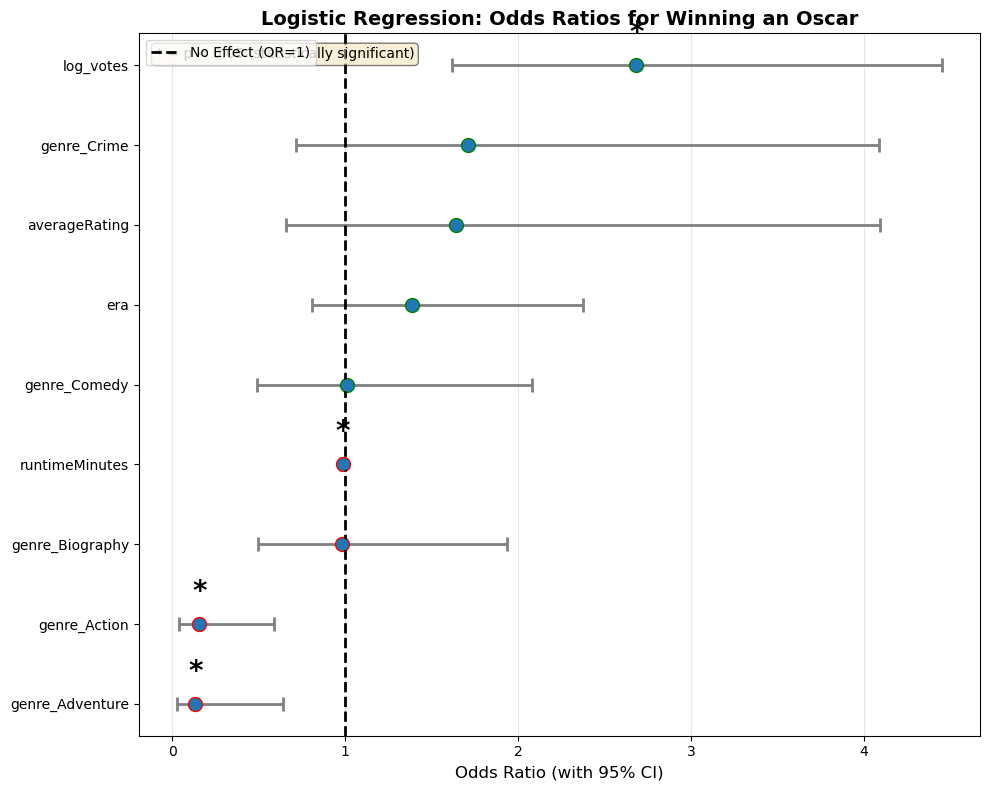

In [38]:
# Plot odds ratios with confidence intervals
fig, ax = plt.subplots(figsize=(10, 8))

# Prepare data (exclude intercept)
plot_data = coef_df.drop('const', errors='ignore').sort_values('Odds Ratio')

y_pos = np.arange(len(plot_data))

# Plot odds ratios as points with error bars
ax.errorbar(plot_data['Odds Ratio'], y_pos, 
            xerr=[plot_data['Odds Ratio'] - plot_data['95% CI Lower'],
                  plot_data['95% CI Upper'] - plot_data['Odds Ratio']],
            fmt='o', markersize=8, capsize=5, capthick=2,
            ecolor='gray', elinewidth=2)

# Color points by direction of effect
for i, (idx, row) in enumerate(plot_data.iterrows()):
    color = 'green' if row['Odds Ratio'] > 1 else 'red'
    ax.plot(row['Odds Ratio'], i, 'o', markersize=10, color=color)

    # Add asterisk for significant predictors
    if row['P-value'] < 0.05:
        ax.text(row['Odds Ratio'], i + 0.3, '*', 
                fontsize=20, ha='center', fontweight='bold')

# Reference line at 1 (no effect)
ax.axvline(x=1, color='black', linestyle='--', linewidth=2, label='No Effect (OR=1)')

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data.index)
ax.set_xlabel('Odds Ratio (with 95% CI)', fontsize=12)
ax.set_title('Logistic Regression: Odds Ratios for Winning an Oscar', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Add text annotation
ax.text(0.02, 0.98, '* = p < 0.05 (statistically significant)',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()

print()


### Interpretation of the Logistic Regression Results

Our logistic regression model provides the most nuanced answer to our research question: does genre remain a significant predictor of an Oscar win after controlling for film quality, popularity, and temporal factors? The results indicate that while a universal "prestige bias" does not exist across all genres, specific genres do face severe, statistically significant penalties.

**1. Significant Genre Penalties (Action & Adventure)**
Using Drama as our baseline reference category, the model revealed massive penalties for blockbuster genres. 
* **Action:** Films in the Action genre have an odds ratio of 0.158 (p = 0.0061). This means that, holding quality, popularity, and runtime constant, an Action film faces an 84.2% decrease in the odds of winning compared to a Drama. 
* **Adventure:** Similarly, Adventure films yield an odds ratio of 0.134 (p = 0.0120), translating to an 86.6% decrease in winning odds compared to a Drama. 
* **Interpretation:** This confirms a highly specific form of genre bias. The Academy does not necessarily elevate Dramas over *all* other genres, but it actively penalizes Action and Adventure films at the final voting stage, even if their critical reception and popularity match those of a Drama.

**2. The Power of Popularity (The Strongest Predictor)**
Interestingly, the most powerful positive predictor of winning an Academy Award was not genre, but public visibility. The `log_votes` variable yielded an odds ratio of 2.685 (p = 0.0001). This indicates a 168.5% increase in the odds of winning for every one-unit increase in log-transformed vote counts. Popularity and cultural footprint—as measured by IMDb voting volume—heavily influence the Academy's final decision.

**3. Non-Significant Factors & "The Nulls"**
Equally important is what the model found to be *insignificant* (p >= 0.05):
* **Biography, Comedy, and Crime:** None of these genres showed a statistically significant difference in winning probability compared to Drama. This contradicts the common assumption that Biopics have an inherent advantage over Dramas, or that Comedies are universally snubbed in the final round. 
* **IMDb Rating:** The `averageRating` (our proxy for baseline film quality) was not a significant predictor (p = 0.2903). This suggests that once a film crosses the threshold of excellence required to secure a nomination, minute differences in general audience ratings no longer sway the Academy. 
* **Era:** The binary `era` variable was not significant in this multivariate context, reinforcing our earlier conclusion that temporal shifts likely manifest in *what* gets nominated or the distribution of runs over time, rather than a flat, linear boost to win probability post-2015.

**4. Model Fit and Overall Explanatory Power**
The logistic regression model achieved reasonable accuracy (84.44%) but demonstrated limited explanatory power (Pseudo R-squared = 0.137), indicating that unmeasured factors drive winning probability more than genre or basic quality metrics. While the 84.44% accuracy seems high, it is only a marginal +1.66 percentage point improvement over simply guessing the baseline majority class (82.78% non-winners). 

**Conclusion:** These fit statistics tell a compelling story: genre, runtime, and basic IMDb metrics capture only a small fraction of why a film wins an Oscar. While being an Action or Adventure film is a distinct liability, the ultimate decision is likely driven by those unmeasured, hidden factors—such as multimillion-dollar studio campaign expenditures, critical momentum from early film festivals, and industry narratives—that transcend standard metadata.

### Justification for Analytical Choices

Several key decisions shaped our analytical approach, and it is important to justify why we made these choices rather than alternatives.

**Why compare winners to nominees rather than to random films?** 

Our decision to restrict the analysis to Oscar nominees (rather than comparing winners to a random sample of all films released during the study period) was deliberate and critical. Comparing winners to random films would conflate two distinct questions: 
1. what makes a film Oscar-worthy in the first place, and 
2. among Oscar-worthy films, what determines who wins.
  
Our research question specifically targets the second question,i.e, we want to know whether genre influences the final voting decision among films that have already been deemed excellent enough to nominate. This approach controls for a major confounder: if Drama films are more likely to win because they are more likely to be high-quality films that deserve recognition, this is not bias—it is meritocracy. By comparing only among nominees, we isolate the effect of genre on the conditional probability of winning given nomination, which is a fairer test of voter bias.

**Why control for IMDb ratings and vote counts?**

One alternative explanation for genre differences in win rates is that certain genres simply produce better films or more popular films, and the Academy recognizes this quality difference. To address this concern, our regression model includes averageRating (a proxy for critical and audience reception) and log_votes (a proxy for cultural impact and visibility). If genre remains a significant predictor even after controlling for these quality metrics, this strengthens the case for bias; if genre effects disappear after controlling for quality, this suggests that apparent genre bias is actually quality bias.

**Why binary era classification rather than continuous year?** We could have modeled time as a continuous variable (year) rather than a binary era indicator. However, the binary approach aligns better with the historical narrative of Academy reforms: the "Oscars So White" controversy and subsequent membership changes represent a discrete intervention rather than a gradual trend. If reforms had an impact, we would expect to see a step change in voting patterns around 2015-2016 rather than a smooth linear trend. The runs test, in particular, is designed to detect such discontinuities. For robustness, the regression model could be extended to include year as a continuous variable or genre × year interaction terms to test whether genre effects have strengthened or weakened linearly over time, but our binary era approach provides a simpler, more interpretable first test of temporal change.


### Potential Limitations of analyses

1. Sample Size and Statistical Power:One of the most significant limitations is the uneven distribution of genres across our 486 nominations. While Drama (168 nominations), Biography (112), and Comedy (90) provide adequate sample sizes for stable inference, smaller genres like Action (38), Adventure (29), Horror (3), and Fantasy (1) are severely underrepresented. This imbalance has two major consequences.First, we were forced to exclude Horror and Fantasy from the chi-squared test because their small sample sizes would violate the assumption that expected cell frequencies should be at least 5. This exclusion means we cannot make definitive claims about whether these genres face bias, and this is a notable gap given that Horror films are often cited as systematically undervalued by the Academy despite critical acclaim. Second, small sample sizes limit statistical power, increasing the risk of Type II errors where we fail to detect true effects. With only 29 Adventure nominations, for example, we have limited ability to detect modest genre effects unless they are quite large.

   The chi-squared test also flagged one marginal assumption violation: Adventure had an expected winner count of 4.99, just below the recommended threshold of 5. While we retained Adventure because this violation is negligible, it introduces some uncertainty into the p-value's validity.

    Our overall sample of 84 winners is modest for a logistic regression model with 9 predictors, meeting the minimum rule-of-thumb of 10 events per predictor but falling short of ideal standards. With marginal sample sizes, coefficient estimates may have high variance and the model may be sensitive to influential observations. Expanding the dataset by including earlier decades or additional award categories would provide more stable estimates and greater power to detect subtle effects.

2. Data Quality and Measurement Issues: Our analysis relies on IMDb for genre classifications, ratings, and vote counts. While IMDb is widely used and generally reliable, it has important limitations. Genre tags are crowd-sourced and may reflect subjective judgments or inconsistent conventions. Our decision to use only the primary genre (first-listed) introduces measurement error because genre ordering is somewhat arbitrary. Furthermore, by forcing each film into a single category, we lose information about genre hybridity.

    IMDb ratings and vote counts also have limitations as proxies for film quality and popularity. Ratings reflect self-selected user opinions, which may not align with Academy voters' professional standards. Vote counts conflate visibility, polarization, and longevity. For example, a film with high votes may simply have been released on streaming platforms where it reached broader audiences, not necessarily indicating higher quality or cultural impact. 

3. Methodological Constraints: Each statistical test relies on assumptions that, while generally reasonable, are not perfectly satisfied.
- Chi-Squared Test: Independence is not fully guaranteed. A single film can be nominated in multiple categories (e.g., Best Picture and Directing), and these nominations may be correlated through shared factors like high-profile campaigns. Residual dependence may slightly inflate our effective sample size.
- Runs Test: The binary era classification (pre-reform vs. post-reform) oversimplifies the gradual, multi-faceted nature of Academy reforms. Changes included membership expansion, voting rule modifications, and outreach initiatives that occurred over several years rather than at a single moment. Reducing this complexity to 0/1 may fail to capture non-linear or delayed reform effects.
- Logistic Regression: Our model likely suffers from omitted variable bias which refers to the exclusion of important unmeasured predictors. Academy voting is influenced by campaign expenditures, festival awards (Cannes, Sundance, Toronto), critical consensus from trade publications, director/star prestige, narrative timing with social movements, and strategic voting behavior. If any of these correlate with genre, our genre coefficients will be confounded.

### Conclusion

This project investigated whether a film's genre classification significantly influences its probability of winning an Academy Award among nominees from 2004 to 2024. Using chi-squared tests, runs tests, and logistic regression, we analyzed 486 nominations across Best Picture, Directing, Original Screenplay, and Adapted Screenplay categories.

Our findings reveal a nuanced picture. The chi-squared test found no statistically significant association between genre and winning (p = 0.097), suggesting that genre alone does not predict Oscar success among nominees. The logistic regression model achieved reasonable accuracy (84.44%) but demonstrated limited explanatory power (Pseudo $R^2$ = 0.137), indicating that unmeasured factors drive winning probability more than genre or basic quality metrics. However, the runs test detected significant temporal clustering (p < 0.001), revealing that Oscar voting patterns have shifted dramatically between pre-reform and post-reform eras. This temporal finding is particularly provocative: it suggests that Academy reforms following "Oscars So White," the rise of streaming platforms, and evolving cultural conversations about representation have reshaped outcomes in ways that transcend traditional genre categories.

These results challenge the conventional narrative of pervasive genre bias at least at the final voting stage. While Drama and Biography films dominate Oscar wins in absolute numbers, this appears to reflect their prevalence among high-quality, nomination-worthy films rather than systematic voter bias in the final round. This suggests that genre's influence operates more subtly than popular discourse assumes, possibly concentrating at the nomination stage or manifesting through unmeasured mechanisms. Our analysis has important limitations: small sample sizes for certain genres, reliance on IMDb metadata, binary era classification that oversimplifies gradual reforms, and the absence of data on campaigns and precursor awards. Future research should expand the temporal scope, investigate nomination-stage bias, incorporate campaign and festival data, and employ stronger causal inference methods to address these gaps.